# EDA for Customer Support Tickets

Цель:
- загрузить датасет
- применить фиксированный split
- посмотреть распределения таргетов
- изучить длины текстов
- проверить языки
- подготовиться к следующим экспериментам

In [1]:

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

from scipy.sparse import hstack

from itertools import product

from scipy.special import softmax, expit

from __future__ import annotations

import time
from IPython.display import clear_output, display

import random
from contextlib import nullcontext
from typing import Dict, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from tqdm.auto import tqdm

import os
import math
from typing import Dict, Tuple, Optional, List


In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for candidate in [cur] + list(cur.parents):
        if (candidate / "data" / "train_idx.txt").exists():
            return candidate
    raise FileNotFoundError("Не найден корень проекта: нет папки data/ с train_idx.txt")

repo_root = find_repo_root(Path.cwd())
repo_root

WindowsPath('D:/projects2025/VladNLP/homework')

In [4]:
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from eda_benchmark import DATASET, split_df
def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

ds = load_dataset(DATASET)["train"]
df = ds.to_pandas()

print(df.shape)
df.head(3)

(61765, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, ...",Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroffenen Geräte sowie der ergriffenen ersten Maßnahmen. Wir erkennen die Dringlichke...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to...","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, and our technical team is actively working to resolve the issue. In the meantime...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of your smart home integration products listed on your...","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit. Compatibility details can differ depending on the specific item; please let us ...",Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None


In [ ]:
needed = ["subject", "body", "queue", "priority", "type", "language"]
missing = [c for c in needed if c not in df.columns]

print("Missing columns:", missing)
print("Columns:", df.columns.tolist())

Missing columns: []
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


In [ ]:
splits = split_df(df, repo_root)

for split_name in splits:
    splits[split_name]["type"] = splits[split_name]["type"].fillna("Unknown")

for split_name, split_df_ in splits.items():
    print(split_name, split_df_.shape)

train (49412, 16)
val (6176, 16)
test (6177, 16)


In [ ]:
splits["train"][["subject", "body", "queue", "priority", "type", "language"]].head(3)

,subject,body,queue,priority,type,language
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, ...",Technical Support,high,Incident,de
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to...",Technical Support,high,Incident,en
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of your smart home integration products listed on your...",Returns and Exchanges,medium,Request,en


In [ ]:
summary_missing = []

for split_name, split_df_ in splits.items():
    row = {"split": split_name}
    for col in ["subject", "body", "queue", "priority", "type", "language"]:
        row[col] = split_df_[col].isna().mean()
    summary_missing.append(row)

missing_df = pd.DataFrame(summary_missing)
missing_df

,split,subject,body,queue,priority,type,language
0,train,0.086376,0.00004,0.0,0.0,0.0,0.0
1,val,0.081768,0.00000,0.0,0.0,0.0,0.0
2,test,0.085155,0.00000,0.0,0.0,0.0,0.0


In [ ]:
sizes_df = pd.DataFrame({
    "split": list(splits.keys()),
    "n_rows": [len(splits[k]) for k in splits]
})
sizes_df


,split,n_rows
0,train,49412
1,val,6176
2,test,6177


In [ ]:
for split_name in splits:
    splits[split_name]["full_text"] = make_text(splits[split_name])
    splits[split_name]["subject_len_chars"] = splits[split_name]["subject"].fillna("").astype(str).str.len()
    splits[split_name]["body_len_chars"] = splits[split_name]["body"].fillna("").astype(str).str.len()
    splits[split_name]["full_len_chars"] = splits[split_name]["full_text"].str.len()

    splits[split_name]["subject_len_words"] = (
        splits[split_name]["subject"].fillna("").astype(str).str.split().map(len)
    )
    splits[split_name]["body_len_words"] = (
        splits[split_name]["body"].fillna("").astype(str).str.split().map(len)
    )
    splits[split_name]["full_len_words"] = (
        splits[split_name]["full_text"].str.split().map(len)
    )

length_stats = []

for split_name, split_df_ in splits.items():
    row = {
        "split": split_name,
        "full_chars_mean": split_df_["full_len_chars"].mean(),
        "full_chars_p50": split_df_["full_len_chars"].median(),
        "full_chars_p90": split_df_["full_len_chars"].quantile(0.90),
        "full_chars_p99": split_df_["full_len_chars"].quantile(0.99),
        "full_words_mean": split_df_["full_len_words"].mean(),
        "full_words_p50": split_df_["full_len_words"].median(),
        "full_words_p90": split_df_["full_len_words"].quantile(0.90),
        "full_words_p99": split_df_["full_len_words"].quantile(0.99),
    }
    length_stats.append(row)

pd.DataFrame(length_stats)

,split,full_chars_mean,full_chars_p50,full_chars_p90,full_chars_p99,full_words_mean,full_words_p50,full_words_p90,full_words_p99
0,train,464.754635,460.0,755.0,998.89,62.445438,62.0,99.0,143.00
1,val,466.728789,463.0,753.0,1009.50,62.664670,62.0,98.0,142.00
2,test,460.328800,454.0,751.0,1015.24,62.062490,62.0,98.0,147.24


In [ ]:
queue_counts = splits["train"]["queue"].astype(str).value_counts()

display(queue_counts.head(20))
display(queue_counts.tail(20))

queue
Technical Support                      11354
Product Support                         7139
Customer Service                        5905
IT Support                              4673
Billing and Payments                    3853
Returns and Exchanges                   1956
Service Outages and Maintenance         1534
Sales and Pre-Sales                     1228
Human Resources                          730
General Inquiry                          532
News                                     313
Pets & Animals/Pet Services              308
Autos & Vehicles/Sales                   287
IT & Technology/Security Operations      285
Home & Garden/Home Improvement           285
Shopping/E-commerce                      278
Health/Medical Services                  278
Pets & Animals/Veterinary Care           278
Health/Mental Health                     275
Jobs & Education/Online Courses          271
Name: count, dtype: int64

queue
IT & Technology/Network Infrastructure    250
Travel & Transportation/Air Travel        247
Arts & Entertainment/Music                243
Law & Government/Legal Advice             241
Beauty & Fitness/Fitness Training         240
Games                                     237
Autos & Vehicles/Maintenance              237
Science/Research                          237
Jobs & Education/Recruitment              235
Science/Environmental Science             233
Food & Drink/Restaurants                  232
Books & Literature/Fiction                232
Shopping/Retail Stores                    226
People & Society/Culture & Society        220
IT & Technology/Hardware Support          219
Home & Garden/Landscaping                 217
Arts & Entertainment/Movies               207
IT & Technology/Software Development      206
Sports                                    190
Real Estate                               187
Name: count, dtype: int64

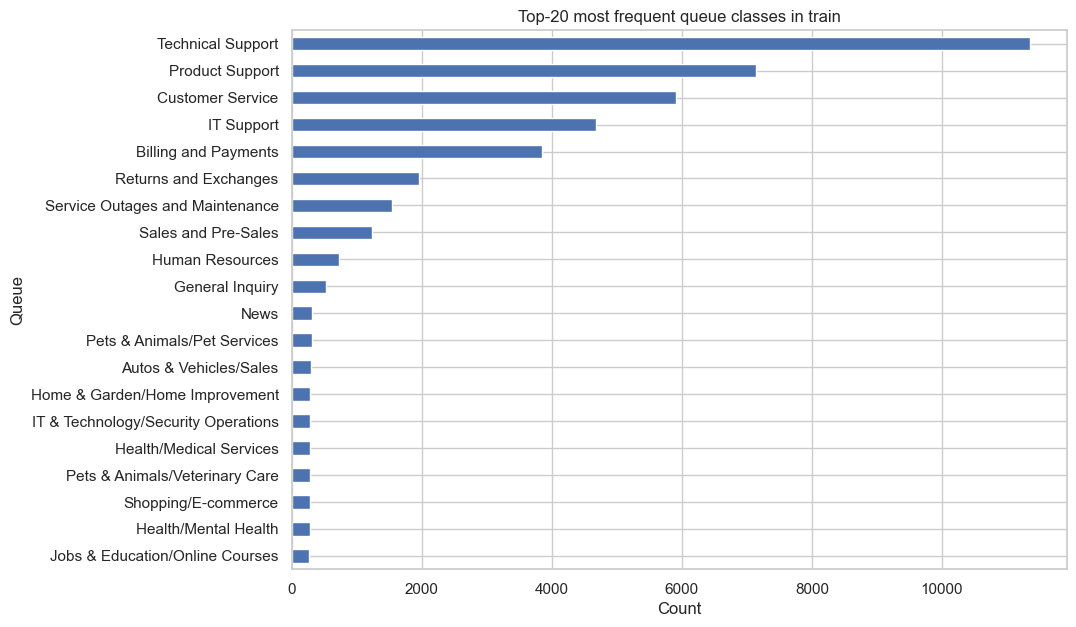

In [ ]:
top_n = 20
top_queue = queue_counts.head(top_n).sort_values()

plt.figure(figsize=(10, 7))
top_queue.plot(kind="barh")
plt.title(f"Top-{top_n} most frequent queue classes in train")
plt.xlabel("Count")
plt.ylabel("Queue")
plt.show()

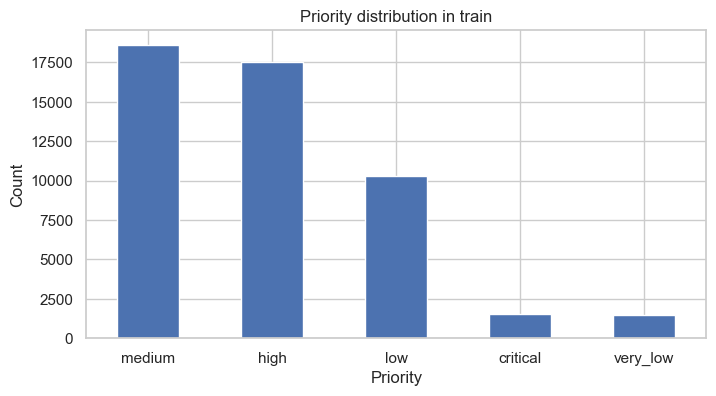

priority
medium      18629
high        17546
low         10280
critical     1516
very_low     1441
Name: count, dtype: int64

In [ ]:
priority_counts = splits["train"]["priority"].astype(str).value_counts()

plt.figure(figsize=(8, 4))
priority_counts.plot(kind="bar")
plt.title("Priority distribution in train")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

priority_counts

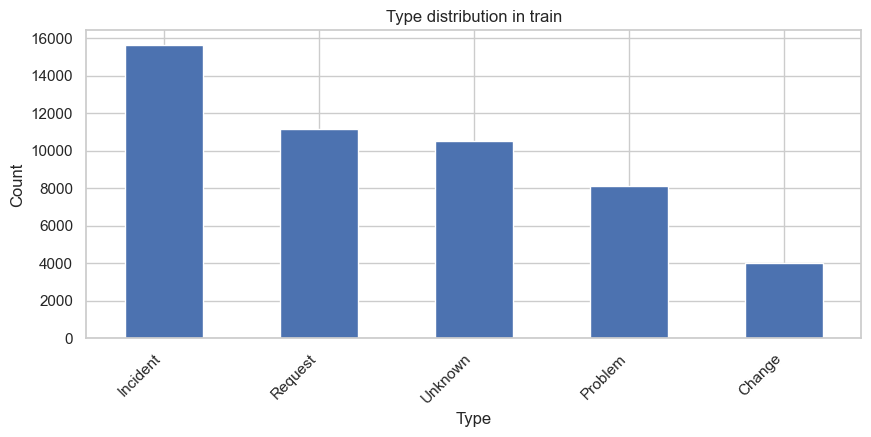

type
Incident    15632
Request     11165
Unknown     10508
Problem      8103
Change       4004
Name: count, dtype: int64

In [ ]:
type_counts = splits["train"]["type"].astype(str).value_counts()

plt.figure(figsize=(10, 4))
type_counts.plot(kind="bar")
plt.title("Type distribution in train")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

type_counts

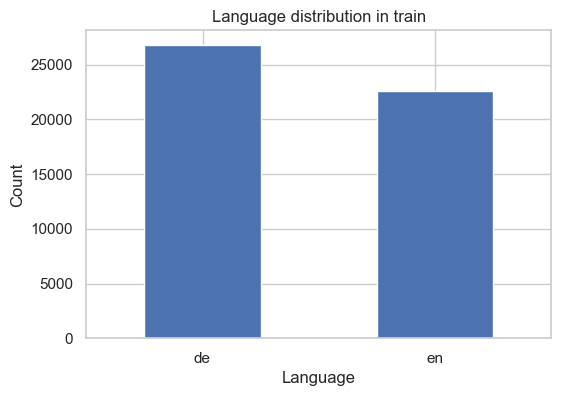

language
de    26799
en    22613
Name: count, dtype: int64

In [ ]:
lang_counts = splits["train"]["language"].fillna("NA").astype(str).value_counts()

plt.figure(figsize=(6, 4))
lang_counts.plot(kind="bar")
plt.title("Language distribution in train")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

lang_counts

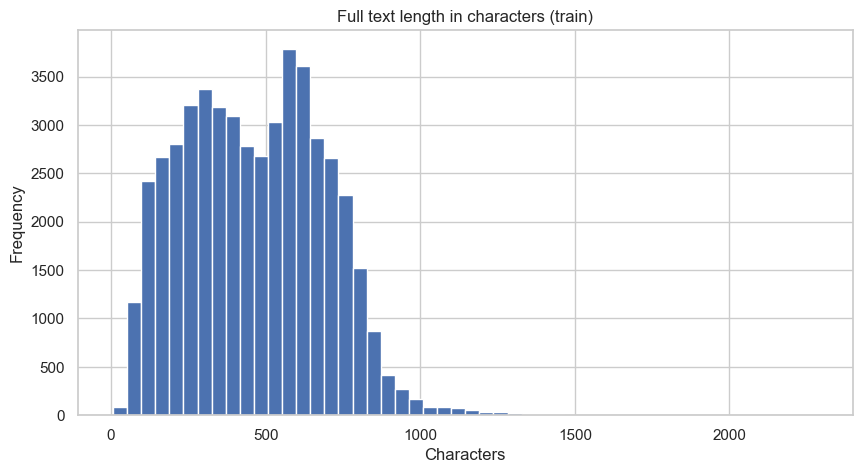

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(splits["train"]["full_len_chars"], bins=50)
plt.title("Full text length in characters (train)")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

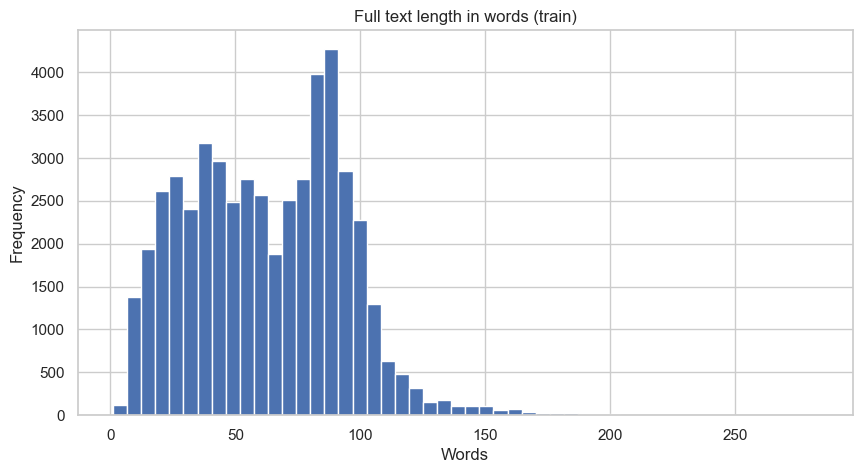

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(splits["train"]["full_len_words"], bins=50)
plt.title("Full text length in words (train)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
lang_len_df = (
    splits["train"]
    .groupby("language", dropna=False)[["full_len_chars", "full_len_words"]]
    .agg(["mean", "median"])
)

lang_len_df

full_len_chars        full_len_words       
                   mean median           mean median
language                                            
de           510.291466  517.0      64.284264   65.0
en           410.788263  406.0      60.266219   59.0

In [ ]:
queue_priority = pd.crosstab(
    splits["train"]["queue"].astype(str),
    splits["train"]["priority"].astype(str),
    normalize="index"
)

queue_priority.head(9)

priority,critical,high,low,medium,very_low
queue,,,,,
Arts & Entertainment/Movies,0.149758,0.125604,0.198068,0.318841,0.207729
Arts & Entertainment/Music,0.131687,0.242798,0.148148,0.275720,0.201646
Autos & Vehicles/Maintenance,0.122363,0.130802,0.210970,0.350211,0.185654
Autos & Vehicles/Sales,0.156794,0.285714,0.198606,0.229965,0.128920
Beauty & Fitness/Cosmetics,0.164000,0.220000,0.288000,0.212000,0.116000
Beauty & Fitness/Fitness Training,0.191667,0.312500,0.158333,0.258333,0.079167
Billing and Payments,0.000000,0.290164,0.221386,0.488451,0.000000
Books & Literature/Fiction,0.206897,0.241379,0.155172,0.219828,0.176724
Books & Literature/Non-Fiction,0.186508,0.214286,0.166667,0.234127,0.198413


In [ ]:
queue_type = pd.crosstab(
    splits["train"]["queue"].astype(str),
    splits["train"]["type"].astype(str),
    normalize="index"
)

queue_type.head(9)

type,Change,Incident,Problem,Request,Unknown
queue,,,,,
Arts & Entertainment/Movies,0.000000,0.000000,0.000000,0.000000,1.0
Arts & Entertainment/Music,0.000000,0.000000,0.000000,0.000000,1.0
Autos & Vehicles/Maintenance,0.000000,0.000000,0.000000,0.000000,1.0
Autos & Vehicles/Sales,0.000000,0.000000,0.000000,0.000000,1.0
Beauty & Fitness/Cosmetics,0.000000,0.000000,0.000000,0.000000,1.0
Beauty & Fitness/Fitness Training,0.000000,0.000000,0.000000,0.000000,1.0
Billing and Payments,0.054243,0.238256,0.214378,0.493122,0.0
Books & Literature/Fiction,0.000000,0.000000,0.000000,0.000000,1.0
Books & Literature/Non-Fiction,0.000000,0.000000,0.000000,0.000000,1.0


In [ ]:
n_queue = splits["train"]["queue"].astype(str).nunique()
n_priority = splits["train"]["priority"].astype(str).nunique()
n_type = splits["train"]["type"].astype(str).nunique()

print("N queue classes:", n_queue)
print("N priority classes:", n_priority)
print("N type classes:", n_type)
print()
print("Top-5 queue counts:")
display(queue_counts.head())
print()
print("Bottom-5 queue counts:")
display(queue_counts.tail())


N queue classes: 52
N priority classes: 5
N type classes: 5

Top-5 queue counts:


queue
Technical Support       11354
Product Support          7139
Customer Service         5905
IT Support               4673
Billing and Payments     3853
Name: count, dtype: int64


Bottom-5 queue counts:


queue
Home & Garden/Landscaping               217
Arts & Entertainment/Movies             207
IT & Technology/Software Development    206
Sports                                  190
Real Estate                             187
Name: count, dtype: int64

In [ ]:
X_train = splits["train"]["full_text"]
X_val = splits["val"]["full_text"]

y_train = splits["train"]["queue"].astype(str)
y_val = splits["val"]["queue"].astype(str)

vec = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1, 2),
    min_df=2,
)

Xtr = vec.fit_transform(X_train)
Xva = vec.transform(X_val)

clf = LinearSVC()
clf.fit(Xtr, y_train)
pred_val = clf.predict(Xva)

In [ ]:
report = classification_report(y_val, pred_val, output_dict=True)
report_df = pd.DataFrame(report).T
report_df.sort_values("f1-score").head(10)

,precision,recall,f1-score,support
General Inquiry,0.958333,0.315068,0.474227,73.000000
Sales and Pre-Sales,0.652778,0.379032,0.479592,124.000000
Returns and Exchanges,0.705882,0.401674,0.512000,239.000000
IT Support,0.551148,0.491620,0.519685,537.000000
Customer Service,0.545103,0.564753,0.554754,749.000000
Product Support,0.560130,0.584842,0.572219,884.000000
Human Resources,0.900000,0.483871,0.629371,93.000000
Technical Support,0.577803,0.732673,0.646087,1414.000000
weighted avg,0.704098,0.689443,0.687784,6176.000000
accuracy,0.689443,0.689443,0.689443,0.689443


In [ ]:
report_df.sort_values("f1-score", ascending=False).head(10)

,precision,recall,f1-score,support
Beauty & Fitness/Fitness Training,1.0,1.0,1.0,23.0
Home & Garden/Landscaping,1.0,1.0,1.0,17.0
Finance/Personal Finance,1.0,1.0,1.0,33.0
Finance/Investments,1.0,1.0,1.0,40.0
Business & Industrial/Manufacturing,1.0,1.0,1.0,43.0
Books & Literature/Non-Fiction,1.0,1.0,1.0,32.0
Books & Literature/Fiction,1.0,1.0,1.0,29.0
Hobbies & Leisure/Crafts,1.0,1.0,1.0,27.0
Online Communities/Forums,1.0,1.0,1.0,39.0
IT & Technology/Software Development,1.0,1.0,1.0,32.0


## Baseline error analysis for `queue`

Цель:
- посмотреть, какие крупные классы путаются между собой
- вывести confusion matrix по трудным классам
- собрать таблицу ошибок
- проверить качество отдельно по языкам

In [ ]:
X_train = splits["train"]["full_text"]
X_val = splits["val"]["full_text"]

y_train = splits["train"]["queue"].astype(str)
y_val = splits["val"]["queue"].astype(str)

vec = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1, 2),
    min_df=2,
)

Xtr = vec.fit_transform(X_train)
Xva = vec.transform(X_val)

clf = LinearSVC()
clf.fit(Xtr, y_train)
pred_val = clf.predict(Xva)

print("Validation accuracy:", round(accuracy_score(y_val, pred_val), 4))
print("Validation macro-F1:", round(f1_score(y_val, pred_val, average="macro"), 4))

Validation accuracy: 0.6894
Validation macro-F1: 0.8986


In [ ]:
val_pred_df = splits["val"].copy()
val_pred_df["true_queue"] = y_val.values
val_pred_df["pred_queue"] = pred_val
val_pred_df["is_correct"] = val_pred_df["true_queue"] == val_pred_df["pred_queue"]

val_pred_df[["subject", "true_queue", "pred_queue", "is_correct"]].head()

,subject,true_queue,pred_queue,is_correct
6,System Interruptions,Service Outages and Maintenance,Service Outages and Maintenance,True
11,Issue with SaaS Platform Functionality,Product Support,Customer Service,False
12,Immediate Help Needed: Technical Problem with Cloud SaaS Service,IT Support,IT Support,True
18,Query About Future Service Disruptions and Maintenance Timelines,Service Outages and Maintenance,Service Outages and Maintenance,True
35,Urgent: Ongoing System Failures Disrupting EMR/PACS Telehealth Services,Technical Support,Technical Support,True


In [ ]:
hard_classes = [
    "Technical Support",
    "IT Support",
    "Product Support",
    "Customer Service",
    "Returns and Exchanges",
    "Sales and Pre-Sales",
    "General Inquiry",
    "Billing and Payments",
    "Service Outages and Maintenance",
]

hard_classes

['Technical Support',
 'IT Support',
 'Product Support',
 'Customer Service',
 'Returns and Exchanges',
 'Sales and Pre-Sales',
 'General Inquiry',
 'Billing and Payments',
 'Service Outages and Maintenance']

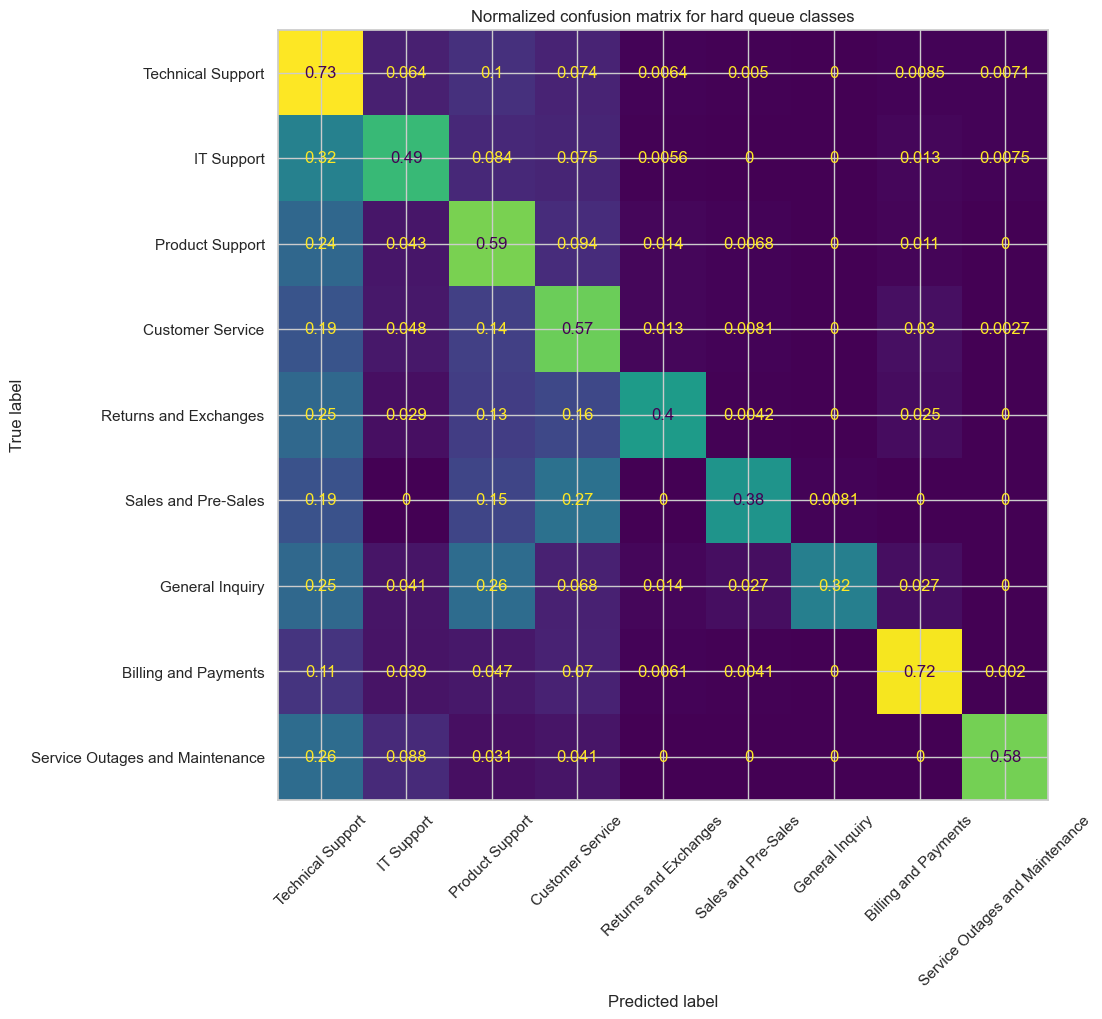

In [ ]:
hard_true_mask = val_pred_df["true_queue"].isin(hard_classes)
hard_true_df = val_pred_df.loc[hard_true_mask].copy()

cm_norm = confusion_matrix(
    hard_true_df["true_queue"],
    hard_true_df["pred_queue"],
    labels=hard_classes,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=hard_classes)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Normalized confusion matrix for hard queue classes")
plt.show()

In [ ]:
hard_report = classification_report(
    hard_true_df["true_queue"],
    hard_true_df["pred_queue"],
    labels=hard_classes,
    output_dict=True,
    zero_division=0,
)

hard_report_df = pd.DataFrame(hard_report).T
hard_report_df

,precision,recall,f1-score,support
Technical Support,0.584980,0.732673,0.650549,1414.0
IT Support,0.555789,0.491620,0.521739,537.0
Product Support,0.568132,0.584842,0.576366,884.0
Customer Service,0.550065,0.564753,0.557312,749.0
Returns and Exchanges,0.716418,0.401674,0.514745,239.0
Sales and Pre-Sales,0.661972,0.379032,0.482051,124.0
General Inquiry,0.958333,0.315068,0.474227,73.0
Billing and Payments,0.856796,0.721881,0.783574,489.0
Service Outages and Maintenance,0.868217,0.577320,0.693498,194.0
micro avg,0.611502,0.610461,0.610981,4703.0


In [ ]:
hard_error_df = val_pred_df[
    (val_pred_df["true_queue"].isin(hard_classes)) &
    (val_pred_df["pred_queue"].isin(hard_classes)) &
    (val_pred_df["true_queue"] != val_pred_df["pred_queue"])
].copy()

hard_error_df.shape

(1824, 26)

In [ ]:
confusion_pairs = (
    hard_error_df
    .groupby(["true_queue", "pred_queue"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusion_pairs.head(20)

,true_queue,pred_queue,count
32,Product Support,Technical Support,216
26,IT Support,Technical Support,173
50,Technical Support,Product Support,145
13,Customer Service,Technical Support,142
48,Technical Support,Customer Service,104
9,Customer Service,Product Support,104
49,Technical Support,IT Support,91
28,Product Support,Customer Service,83
38,Returns and Exchanges,Technical Support,59
6,Billing and Payments,Technical Support,54


,language,n,queue_acc,queue_macro_f1
0,de,3375,0.698370,0.873413
1,en,2801,0.678686,0.605615


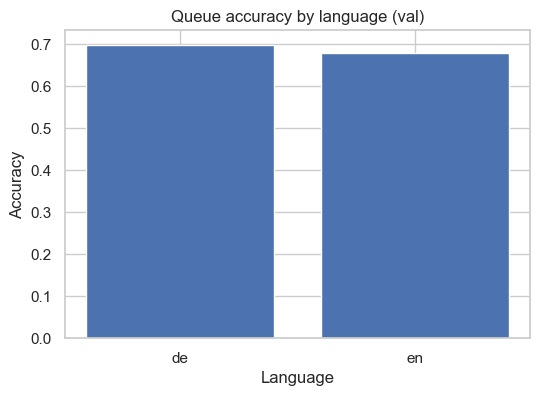

In [ ]:
lang_metrics = []

for lang in sorted(val_pred_df["language"].dropna().unique()):
    sub = val_pred_df[val_pred_df["language"] == lang].copy()

    row = {
        "language": lang,
        "n": len(sub),
        "queue_acc": accuracy_score(sub["true_queue"], sub["pred_queue"]),
        "queue_macro_f1": f1_score(sub["true_queue"], sub["pred_queue"], average="macro"),
    }
    lang_metrics.append(row)

lang_metrics_df = pd.DataFrame(lang_metrics)
display(lang_metrics_df)

plt.figure(figsize=(6, 4))
plt.bar(lang_metrics_df["language"], lang_metrics_df["queue_acc"])
plt.title("Queue accuracy by language (val)")
plt.xlabel("Language")
plt.ylabel("Accuracy")
plt.show()

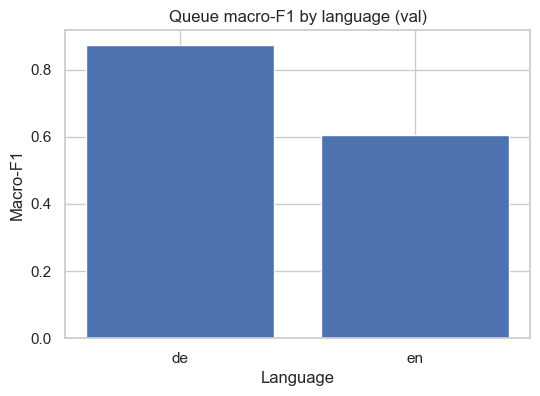

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(lang_metrics_df["language"], lang_metrics_df["queue_macro_f1"])
plt.title("Queue macro-F1 by language (val)")
plt.xlabel("Language")
plt.ylabel("Macro-F1")
plt.show()

In [ ]:
hard_error_lang = (
    hard_error_df["language"]
    .fillna("NA")
    .value_counts()
    .rename_axis("language")
    .reset_index(name="n_errors")
)

hard_error_lang

,language,n_errors
0,de,949
1,en,875


In [ ]:
print("Top confusion pairs:")
display(confusion_pairs.head(10))

print("\nLanguage-specific metrics:")
display(lang_metrics_df)

print("\nHard-class metrics:")
display(
    hard_report_df.loc[hard_classes, ["precision", "recall", "f1-score", "support"]]
    .sort_values("f1-score")
)

Top confusion pairs:


,true_queue,pred_queue,count
32,Product Support,Technical Support,216
26,IT Support,Technical Support,173
50,Technical Support,Product Support,145
13,Customer Service,Technical Support,142
48,Technical Support,Customer Service,104
9,Customer Service,Product Support,104
49,Technical Support,IT Support,91
28,Product Support,Customer Service,83
38,Returns and Exchanges,Technical Support,59
6,Billing and Payments,Technical Support,54



Language-specific metrics:


,language,n,queue_acc,queue_macro_f1
0,de,3375,0.698370,0.873413
1,en,2801,0.678686,0.605615



Hard-class metrics:


,precision,recall,f1-score,support
General Inquiry,0.958333,0.315068,0.474227,73.0
Sales and Pre-Sales,0.661972,0.379032,0.482051,124.0
Returns and Exchanges,0.716418,0.401674,0.514745,239.0
IT Support,0.555789,0.491620,0.521739,537.0
Customer Service,0.550065,0.564753,0.557312,749.0
Product Support,0.568132,0.584842,0.576366,884.0
Technical Support,0.584980,0.732673,0.650549,1414.0
Service Outages and Maintenance,0.868217,0.577320,0.693498,194.0
Billing and Payments,0.856796,0.721881,0.783574,489.0


## Classical model experiments

Сравниваем:
- word TF-IDF + LinearSVC
- char TF-IDF + LinearSVC
- word + char TF-IDF + LinearSVC
- word + char TF-IDF + LinearSVC с усиленным subject

In [ ]:
def make_text_subject_body(df: pd.DataFrame, subject_repeat: int = 1) -> pd.Series:
    subject = df["subject"].fillna("").astype(str)
    body = df["body"].fillna("").astype(str)

    texts = []
    for s, b in zip(subject.tolist(), body.tolist()):
        s_block = "\n".join([s] * max(subject_repeat, 1))
        texts.append(s_block + "\n\n" + b)

    return pd.Series(texts, index=df.index)

In [ ]:
def evaluate_queue_predictions(y_true, y_pred) -> dict:
    return {
        "queue_acc": accuracy_score(y_true, y_pred),
        "queue_macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


def evaluate_by_language(df_with_pred: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for lang in sorted(df_with_pred["language"].dropna().unique()):
        sub = df_with_pred[df_with_pred["language"] == lang].copy()
        rows.append({
            "language": lang,
            "n": len(sub),
            "queue_acc": accuracy_score(sub["true_queue"], sub["pred_queue"]),
            "queue_macro_f1": f1_score(sub["true_queue"], sub["pred_queue"], average="macro"),
        })
    return pd.DataFrame(rows)

In [ ]:
X_train_word = make_text_subject_body(splits["train"], subject_repeat=1)
X_val_word = make_text_subject_body(splits["val"], subject_repeat=1)

y_train = splits["train"]["queue"].astype(str).values
y_val = splits["val"]["queue"].astype(str).values

word_vec = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1, 2),
    min_df=2,
)

Xtr_word = word_vec.fit_transform(X_train_word)
Xva_word = word_vec.transform(X_val_word)

word_clf = LinearSVC()
word_clf.fit(Xtr_word, y_train)
pred_word = word_clf.predict(Xva_word)

word_metrics = evaluate_queue_predictions(y_val, pred_word)
word_metrics

{'queue_acc': 0.6894430051813472, 'queue_macro_f1': 0.8985881496472607}

In [ ]:
char_vec = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=200_000,
)

Xtr_char = char_vec.fit_transform(X_train_word)
Xva_char = char_vec.transform(X_val_word)

char_clf = LinearSVC()
char_clf.fit(Xtr_char, y_train)
pred_char = char_clf.predict(Xva_char)

char_metrics = evaluate_queue_predictions(y_val, pred_char)
char_metrics

{'queue_acc': 0.6081606217616581, 'queue_macro_f1': 0.878123163773785}

In [ ]:
Xtr_word_char = hstack([Xtr_word, Xtr_char])
Xva_word_char = hstack([Xva_word, Xva_char])

word_char_clf = LinearSVC()
word_char_clf.fit(Xtr_word_char, y_train)
pred_word_char = word_char_clf.predict(Xva_word_char)

word_char_metrics = evaluate_queue_predictions(y_val, pred_word_char)
word_char_metrics

{'queue_acc': 0.6978626943005182, 'queue_macro_f1': 0.9091580925969274}

In [ ]:
X_train_weighted = make_text_subject_body(splits["train"], subject_repeat=3)
X_val_weighted = make_text_subject_body(splits["val"], subject_repeat=3)

word_vec_w = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1, 2),
    min_df=2,
)

char_vec_w = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=200_000,
)

Xtr_word_w = word_vec_w.fit_transform(X_train_weighted)
Xva_word_w = word_vec_w.transform(X_val_weighted)

Xtr_char_w = char_vec_w.fit_transform(X_train_weighted)
Xva_char_w = char_vec_w.transform(X_val_weighted)

Xtr_weighted = hstack([Xtr_word_w, Xtr_char_w])
Xva_weighted = hstack([Xva_word_w, Xva_char_w])

weighted_clf = LinearSVC()
weighted_clf.fit(Xtr_weighted, y_train)
pred_weighted = weighted_clf.predict(Xva_weighted)

weighted_metrics = evaluate_queue_predictions(y_val, pred_weighted)
weighted_metrics

{'queue_acc': 0.6839378238341969, 'queue_macro_f1': 0.9016672380804859}

In [ ]:
comparison_df = pd.DataFrame([
    {"model": "word_tfidf_svc", **word_metrics},
    {"model": "char_tfidf_svc", **char_metrics},
    {"model": "word_char_tfidf_svc", **word_char_metrics},
    {"model": "word_char_tfidf_svc_subjectx3", **weighted_metrics},
])

comparison_df.sort_values("queue_macro_f1", ascending=False)

,model,queue_acc,queue_macro_f1
2,word_char_tfidf_svc,0.697863,0.909158
3,word_char_tfidf_svc_subjectx3,0.683938,0.901667
0,word_tfidf_svc,0.689443,0.898588
1,char_tfidf_svc,0.608161,0.878123


In [ ]:
def build_pred_df(base_df: pd.DataFrame, pred, model_name: str) -> pd.DataFrame:
    out = base_df.copy()
    out["true_queue"] = out["queue"].astype(str)
    out["pred_queue"] = pred
    out["model"] = model_name
    return out


pred_dfs = [
    build_pred_df(splits["val"], pred_word, "word_tfidf_svc"),
    build_pred_df(splits["val"], pred_char, "char_tfidf_svc"),
    build_pred_df(splits["val"], pred_word_char, "word_char_tfidf_svc"),
    build_pred_df(splits["val"], pred_weighted, "word_char_tfidf_svc_subjectx3"),
]

lang_eval_rows = []
for df_pred in pred_dfs:
    model_name = df_pred["model"].iloc[0]
    lang_df = evaluate_by_language(df_pred)
    lang_df["model"] = model_name
    lang_eval_rows.append(lang_df)

lang_eval_df = pd.concat(lang_eval_rows, ignore_index=True)
lang_eval_df.sort_values(["language", "queue_macro_f1"], ascending=[True, False])

,language,n,queue_acc,queue_macro_f1,model
4,de,3375,0.709926,0.883771,word_char_tfidf_svc
6,de,3375,0.698074,0.880715,word_char_tfidf_svc_subjectx3
0,de,3375,0.698370,0.873413,word_tfidf_svc
2,de,3375,0.669630,0.863019,char_tfidf_svc
5,en,2801,0.683327,0.678652,word_char_tfidf_svc
7,en,2801,0.666905,0.652304,word_char_tfidf_svc_subjectx3
1,en,2801,0.678686,0.605615,word_tfidf_svc
3,en,2801,0.534095,0.491353,char_tfidf_svc


In [ ]:
def evaluate_on_hard_classes(base_df: pd.DataFrame, pred, hard_classes: list[str]) -> dict:
    df_tmp = base_df.copy()
    df_tmp["true_queue"] = df_tmp["queue"].astype(str)
    df_tmp["pred_queue"] = pred

    sub = df_tmp[df_tmp["true_queue"].isin(hard_classes)].copy()

    return {
        "n_hard": len(sub),
        "hard_acc": accuracy_score(sub["true_queue"], sub["pred_queue"]),
        "hard_macro_f1": f1_score(sub["true_queue"], sub["pred_queue"], average="macro"),
    }


hard_comparison_df = pd.DataFrame([
    {"model": "word_tfidf_svc", **evaluate_on_hard_classes(splits["val"], pred_word, hard_classes)},
    {"model": "char_tfidf_svc", **evaluate_on_hard_classes(splits["val"], pred_char, hard_classes)},
    {"model": "word_char_tfidf_svc", **evaluate_on_hard_classes(splits["val"], pred_word_char, hard_classes)},
    {"model": "word_char_tfidf_svc_subjectx3", **evaluate_on_hard_classes(splits["val"], pred_weighted, hard_classes)},
])

hard_comparison_df.sort_values("hard_macro_f1", ascending=False)

,model,n_hard,hard_acc,hard_macro_f1
3,word_char_tfidf_svc_subjectx3,4703,0.601531,0.474197
2,word_char_tfidf_svc,4703,0.618329,0.448434
0,word_tfidf_svc,4703,0.610461,0.437839
1,char_tfidf_svc,4703,0.504359,0.333365


In [ ]:
print("Overall validation comparison:")
display(comparison_df.sort_values("queue_macro_f1", ascending=False))

print("\nLanguage-specific comparison:")
display(lang_eval_df.sort_values(["language", "queue_macro_f1"], ascending=[True, False]))

print("\nHard-class comparison:")
display(hard_comparison_df.sort_values("hard_macro_f1", ascending=False))

Overall validation comparison:


,model,queue_acc,queue_macro_f1
2,word_char_tfidf_svc,0.697863,0.909158
3,word_char_tfidf_svc_subjectx3,0.683938,0.901667
0,word_tfidf_svc,0.689443,0.898588
1,char_tfidf_svc,0.608161,0.878123



Language-specific comparison:


,language,n,queue_acc,queue_macro_f1,model
4,de,3375,0.709926,0.883771,word_char_tfidf_svc
6,de,3375,0.698074,0.880715,word_char_tfidf_svc_subjectx3
0,de,3375,0.698370,0.873413,word_tfidf_svc
2,de,3375,0.669630,0.863019,char_tfidf_svc
5,en,2801,0.683327,0.678652,word_char_tfidf_svc
7,en,2801,0.666905,0.652304,word_char_tfidf_svc_subjectx3
1,en,2801,0.678686,0.605615,word_tfidf_svc
3,en,2801,0.534095,0.491353,char_tfidf_svc



Hard-class comparison:


,model,n_hard,hard_acc,hard_macro_f1
3,word_char_tfidf_svc_subjectx3,4703,0.601531,0.474197
2,word_char_tfidf_svc,4703,0.618329,0.448434
0,word_tfidf_svc,4703,0.610461,0.437839
1,char_tfidf_svc,4703,0.504359,0.333365


## Word + Char TF-IDF grid experiments

Проверяем:
- word min_df
- char ngram range
- C у LinearSVC
- умеренное усиление subject

In [ ]:
def make_text_subject_body(df: pd.DataFrame, subject_repeat: int = 1) -> pd.Series:
    subject = df["subject"].fillna("").astype(str)
    body = df["body"].fillna("").astype(str)

    texts = []
    repeat = max(subject_repeat, 1)

    for s, b in zip(subject.tolist(), body.tolist()):
        s_block = "\n".join([s] * repeat)
        texts.append(s_block + "\n\n" + b)

    return pd.Series(texts, index=df.index)


def evaluate_queue(y_true, y_pred) -> dict:
    return {
        "queue_acc": accuracy_score(y_true, y_pred),
        "queue_macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


def evaluate_hard_subset(base_df: pd.DataFrame, pred, hard_classes: list[str]) -> dict:
    tmp = base_df.copy()
    tmp["true_queue"] = tmp["queue"].astype(str)
    tmp["pred_queue"] = pred

    sub = tmp[tmp["true_queue"].isin(hard_classes)].copy()

    return {
        "n_hard": len(sub),
        "hard_acc": accuracy_score(sub["true_queue"], sub["pred_queue"]),
        "hard_macro_f1": f1_score(sub["true_queue"], sub["pred_queue"], average="macro"),
    }


def evaluate_by_language(base_df: pd.DataFrame, pred) -> pd.DataFrame:
    tmp = base_df.copy()
    tmp["true_queue"] = tmp["queue"].astype(str)
    tmp["pred_queue"] = pred

    rows = []
    for lang in sorted(tmp["language"].dropna().unique()):
        sub = tmp[tmp["language"] == lang].copy()
        rows.append({
            "language": lang,
            "n": len(sub),
            "queue_acc": accuracy_score(sub["true_queue"], sub["pred_queue"]),
            "queue_macro_f1": f1_score(sub["true_queue"], sub["pred_queue"], average="macro"),
        })

    return pd.DataFrame(rows)

In [ ]:
def run_word_char_experiment(
    splits: dict,
    hard_classes: list[str],
    word_min_df: int = 2,
    char_ngram_range: tuple = (3, 5),
    C: float = 1.0,
    subject_repeat: int = 1,
    max_features_word: int = 200_000,
    max_features_char: int = 200_000,
):
    X_train_text = make_text_subject_body(splits["train"], subject_repeat=subject_repeat)
    X_val_text = make_text_subject_body(splits["val"], subject_repeat=subject_repeat)

    y_train = splits["train"]["queue"].astype(str).values
    y_val = splits["val"]["queue"].astype(str).values

    word_vec = TfidfVectorizer(
        max_features=max_features_word,
        ngram_range=(1, 2),
        min_df=word_min_df,
    )

    char_vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=char_ngram_range,
        min_df=2,
        max_features=max_features_char,
    )

    Xtr_word = word_vec.fit_transform(X_train_text)
    Xva_word = word_vec.transform(X_val_text)

    Xtr_char = char_vec.fit_transform(X_train_text)
    Xva_char = char_vec.transform(X_val_text)

    Xtr = hstack([Xtr_word, Xtr_char])
    Xva = hstack([Xva_word, Xva_char])

    clf = LinearSVC(C=C)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xva)

    overall = evaluate_queue(y_val, pred)
    hard = evaluate_hard_subset(splits["val"], pred, hard_classes)
    lang_df = evaluate_by_language(splits["val"], pred)

    out = {
        "word_min_df": word_min_df,
        "char_ngram_range": str(char_ngram_range),
        "C": C,
        "subject_repeat": subject_repeat,
        **overall,
        **hard,
        "de_macro_f1": float(lang_df.loc[lang_df["language"] == "de", "queue_macro_f1"].iloc[0]),
        "en_macro_f1": float(lang_df.loc[lang_df["language"] == "en", "queue_macro_f1"].iloc[0]),
        "de_acc": float(lang_df.loc[lang_df["language"] == "de", "queue_acc"].iloc[0]),
        "en_acc": float(lang_df.loc[lang_df["language"] == "en", "queue_acc"].iloc[0]),
    }

    return out, pred

In [ ]:
grid = {
    "word_min_df": [1],
    "char_ngram_range": [(3, 6)],
    "C": [2.0],
    "subject_repeat": [1],
}

grid

{'word_min_df': [1],
 'char_ngram_range': [(3, 6)],
 'C': [2.0],
 'subject_repeat': [1]}

In [ ]:
results = []
pred_store = {}

configs = list(product(
    grid["word_min_df"],
    grid["char_ngram_range"],
    grid["C"],
    grid["subject_repeat"],
))

print(f"Total experiments: {len(configs)}")

for word_min_df, char_ngram_range, C, subject_repeat in configs:
    res, pred = run_word_char_experiment(
        splits=splits,
        hard_classes=hard_classes,
        word_min_df=word_min_df,
        char_ngram_range=char_ngram_range,
        C=C,
        subject_repeat=subject_repeat,
    )

    key = (
        f"word_min_df={word_min_df} | "
        f"char={char_ngram_range} | "
        f"C={C} | "
        f"subject_repeat={subject_repeat}"
    )

    results.append(res)
    pred_store[key] = pred

results_df = pd.DataFrame(results)
results_df.sort_values("queue_macro_f1", ascending=False).head(20)

Total experiments: 1


,word_min_df,char_ngram_range,C,subject_repeat,queue_acc,queue_macro_f1,n_hard,hard_acc,hard_macro_f1,de_macro_f1,en_macro_f1,de_acc,en_acc
0,1,"(3, 6)",2.0,1,0.707902,0.91383,4703,0.629598,0.460865,0.887579,0.705661,0.714963,0.699393


In [ ]:
results_df.sort_values(
    ["queue_macro_f1", "queue_acc", "en_macro_f1", "hard_macro_f1"],
    ascending=[False, False, False, False]
).head(10)

,word_min_df,char_ngram_range,C,subject_repeat,queue_acc,queue_macro_f1,n_hard,hard_acc,hard_macro_f1,de_macro_f1,en_macro_f1,de_acc,en_acc
0,1,"(3, 6)",2.0,1,0.707902,0.91383,4703,0.629598,0.460865,0.887579,0.705661,0.714963,0.699393


In [ ]:
results_df.sort_values(
    ["hard_macro_f1", "queue_macro_f1", "en_macro_f1"],
    ascending=[False, False, False]
).head(10)

,word_min_df,char_ngram_range,C,subject_repeat,queue_acc,queue_macro_f1,n_hard,hard_acc,hard_macro_f1,de_macro_f1,en_macro_f1,de_acc,en_acc
0,1,"(3, 6)",2.0,1,0.707902,0.91383,4703,0.629598,0.460865,0.887579,0.705661,0.714963,0.699393


In [ ]:
results_df.sort_values(
    ["en_macro_f1", "queue_macro_f1", "hard_macro_f1"],
    ascending=[False, False, False]
).head(10)

,word_min_df,char_ngram_range,C,subject_repeat,queue_acc,queue_macro_f1,n_hard,hard_acc,hard_macro_f1,de_macro_f1,en_macro_f1,de_acc,en_acc
0,1,"(3, 6)",2.0,1,0.707902,0.91383,4703,0.629598,0.460865,0.887579,0.705661,0.714963,0.699393


In [ ]:
results_df.sort_values(
    ["de_macro_f1", "queue_macro_f1"],
    ascending=[False, False]
).head(10)

,word_min_df,char_ngram_range,C,subject_repeat,queue_acc,queue_macro_f1,n_hard,hard_acc,hard_macro_f1,de_macro_f1,en_macro_f1,de_acc,en_acc
0,1,"(3, 6)",2.0,1,0.707902,0.91383,4703,0.629598,0.460865,0.887579,0.705661,0.714963,0.699393


In [ ]:
best_row = results_df.sort_values(
    ["queue_macro_f1", "queue_acc", "en_macro_f1", "hard_macro_f1"],
    ascending=[False, False, False, False]
).iloc[0]

best_row

word_min_df                1
char_ngram_range      (3, 6)
C                        2.0
subject_repeat             1
queue_acc           0.707902
queue_macro_f1       0.91383
n_hard                  4703
hard_acc            0.629598
hard_macro_f1       0.460865
de_macro_f1         0.887579
en_macro_f1         0.705661
de_acc              0.714963
en_acc              0.699393
Name: 0, dtype: object

In [ ]:
best_key = (
    f"word_min_df={int(best_row['word_min_df'])} | "
    f"char={eval(best_row['char_ngram_range'])} | "
    f"C={best_row['C']} | "
    f"subject_repeat={int(best_row['subject_repeat'])}"
)

best_key

'word_min_df=1 | char=(3, 6) | C=2.0 | subject_repeat=1'

## Final evaluation of the best word+char model

Считаем:
1. `train -> val`
2. `train -> test`
3. `train+val -> test`  (финальная версия после выбора гиперпараметров)

In [ ]:
BEST_PARAMS = {
    "word_min_df": 1,
    "char_ngram_range": (3, 6),
    "C": 2.0,
    "subject_repeat": 1,
    "max_features_word": 200_000,
    "max_features_char": 200_000,
}

BEST_PARAMS

{'word_min_df': 1,
 'char_ngram_range': (3, 6),
 'C': 2.0,
 'subject_repeat': 1,
 'max_features_word': 200000,
 'max_features_char': 200000}

In [ ]:
def make_text_subject_body(df: pd.DataFrame, subject_repeat: int = 1) -> pd.Series:
    subject = df["subject"].fillna("").astype(str)
    body = df["body"].fillna("").astype(str)

    texts = []
    repeat = max(subject_repeat, 1)

    for s, b in zip(subject.tolist(), body.tolist()):
        s_block = "\n".join([s] * repeat)
        texts.append(s_block + "\n\n" + b)

    return pd.Series(texts, index=df.index)


def fit_predict_word_char_svc(
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    target: str,
    word_min_df: int,
    char_ngram_range: tuple,
    C: float,
    subject_repeat: int,
    max_features_word: int = 200_000,
    max_features_char: int = 200_000,
):
    X_train_text = make_text_subject_body(train_df, subject_repeat=subject_repeat)
    X_eval_text = make_text_subject_body(eval_df, subject_repeat=subject_repeat)

    y_train = train_df[target].astype(str).values
    y_eval = eval_df[target].astype(str).values

    word_vec = TfidfVectorizer(
        max_features=max_features_word,
        ngram_range=(1, 2),
        min_df=word_min_df,
    )

    char_vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=char_ngram_range,
        min_df=2,
        max_features=max_features_char,
    )

    Xtr_word = word_vec.fit_transform(X_train_text)
    Xev_word = word_vec.transform(X_eval_text)

    Xtr_char = char_vec.fit_transform(X_train_text)
    Xev_char = char_vec.transform(X_eval_text)

    Xtr = hstack([Xtr_word, Xtr_char])
    Xev = hstack([Xev_word, Xev_char])

    clf = LinearSVC(C=C)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xev)

    metrics = {
        "target": target,
        "acc": accuracy_score(y_eval, pred),
    }

    if target == "queue":
        metrics["macro_f1"] = f1_score(y_eval, pred, average="macro")

    return pred, metrics


def evaluate_queue_by_language(eval_df: pd.DataFrame, pred) -> pd.DataFrame:
    tmp = eval_df.copy()
    tmp["true_queue"] = tmp["queue"].astype(str)
    tmp["pred_queue"] = pred

    rows = []
    for lang in sorted(tmp["language"].dropna().unique()):
        sub = tmp[tmp["language"] == lang].copy()
        rows.append({
            "language": lang,
            "n": len(sub),
            "queue_acc": accuracy_score(sub["true_queue"], sub["pred_queue"]),
            "queue_macro_f1": f1_score(sub["true_queue"], sub["pred_queue"], average="macro"),
        })

    return pd.DataFrame(rows)


def compute_final_score(queue_metrics: dict, priority_metrics: dict, type_metrics: dict) -> float:
    return (
        0.70 * queue_metrics["macro_f1"]
        + 0.15 * priority_metrics["acc"]
        + 0.15 * type_metrics["acc"]
    )

In [ ]:
queue_pred_val, queue_metrics_val = fit_predict_word_char_svc(
    train_df=splits["train"],
    eval_df=splits["val"],
    target="queue",
    **BEST_PARAMS,
)

queue_pred_test_from_train, queue_metrics_test_from_train = fit_predict_word_char_svc(
    train_df=splits["train"],
    eval_df=splits["test"],
    target="queue",
    **BEST_PARAMS,
)

pd.DataFrame([
    {"setup": "train -> val", **queue_metrics_val},
    {"setup": "train -> test", **queue_metrics_test_from_train},
])

,setup,target,acc,macro_f1
0,train -> val,queue,0.707902,0.913830
1,train -> test,queue,0.704873,0.915261


In [ ]:
print("Validation by language:")
display(evaluate_queue_by_language(splits["val"], queue_pred_val))

print("Test by language (trained on train only):")
display(evaluate_queue_by_language(splits["test"], queue_pred_test_from_train))

Validation by language:


,language,n,queue_acc,queue_macro_f1
0,de,3375,0.714963,0.887579
1,en,2801,0.699393,0.705661


Test by language (trained on train only):


,language,n,queue_acc,queue_macro_f1
0,de,3330,0.695495,0.885878
1,en,2847,0.715841,0.701438


In [ ]:
trainval_df = pd.concat([splits["train"], splits["val"]], axis=0).reset_index(drop=True)

queue_pred_test_final, queue_metrics_test_final = fit_predict_word_char_svc(
    train_df=trainval_df,
    eval_df=splits["test"],
    target="queue",
    **BEST_PARAMS,
)

pd.DataFrame([
    {"setup": "train+val -> test", **queue_metrics_test_final},
])

,setup,target,acc,macro_f1
0,train+val -> test,queue,0.717662,0.92127


In [ ]:
evaluate_queue_by_language(splits["test"], queue_pred_test_final)

,language,n,queue_acc,queue_macro_f1
0,de,3330,0.701502,0.890633
1,en,2847,0.736565,0.721790


In [ ]:
priority_pred_val, priority_metrics_val = fit_predict_word_char_svc(
    train_df=splits["train"],
    eval_df=splits["val"],
    target="priority",
    **BEST_PARAMS,
)

type_pred_val, type_metrics_val = fit_predict_word_char_svc(
    train_df=splits["train"],
    eval_df=splits["val"],
    target="type",
    **BEST_PARAMS,
)

val_score = compute_final_score(queue_metrics_val, priority_metrics_val, type_metrics_val)

pd.DataFrame([
    {
        "setup": "train -> val",
        "queue_acc": queue_metrics_val["acc"],
        "queue_macro_f1": queue_metrics_val["macro_f1"],
        "priority_acc": priority_metrics_val["acc"],
        "type_acc": type_metrics_val["acc"],
        "final_score": val_score,
    }
])

,setup,queue_acc,queue_macro_f1,priority_acc,type_acc,final_score
0,train -> val,0.707902,0.91383,0.729598,0.895078,0.883383


In [ ]:
priority_pred_test_from_train, priority_metrics_test_from_train = fit_predict_word_char_svc(
    train_df=splits["train"],
    eval_df=splits["test"],
    target="priority",
    **BEST_PARAMS,
)

type_pred_test_from_train, type_metrics_test_from_train = fit_predict_word_char_svc(
    train_df=splits["train"],
    eval_df=splits["test"],
    target="type",
    **BEST_PARAMS,
)

test_score_from_train = compute_final_score(
    queue_metrics_test_from_train,
    priority_metrics_test_from_train,
    type_metrics_test_from_train,
)

pd.DataFrame([
    {
        "setup": "train -> test",
        "queue_acc": queue_metrics_test_from_train["acc"],
        "queue_macro_f1": queue_metrics_test_from_train["macro_f1"],
        "priority_acc": priority_metrics_test_from_train["acc"],
        "type_acc": type_metrics_test_from_train["acc"],
        "final_score": test_score_from_train,
    }
])

,setup,queue_acc,queue_macro_f1,priority_acc,type_acc,final_score
0,train -> test,0.704873,0.915261,0.720091,0.901085,0.883859


In [ ]:
priority_pred_test_final, priority_metrics_test_final = fit_predict_word_char_svc(
    train_df=trainval_df,
    eval_df=splits["test"],
    target="priority",
    **BEST_PARAMS,
)

type_pred_test_final, type_metrics_test_final = fit_predict_word_char_svc(
    train_df=trainval_df,
    eval_df=splits["test"],
    target="type",
    **BEST_PARAMS,
)

final_test_score = compute_final_score(
    queue_metrics_test_final,
    priority_metrics_test_final,
    type_metrics_test_final,
)

pd.DataFrame([
    {
        "setup": "train+val -> test",
        "queue_acc": queue_metrics_test_final["acc"],
        "queue_macro_f1": queue_metrics_test_final["macro_f1"],
        "priority_acc": priority_metrics_test_final["acc"],
        "type_acc": type_metrics_test_final["acc"],
        "final_score": final_test_score,
    }
])

,setup,queue_acc,queue_macro_f1,priority_acc,type_acc,final_score
0,train+val -> test,0.717662,0.92127,0.737575,0.904646,0.891222


In [ ]:
summary_df = pd.DataFrame([
    {
        "setup": "train -> val",
        "queue_acc": queue_metrics_val["acc"],
        "queue_macro_f1": queue_metrics_val["macro_f1"],
        "priority_acc": priority_metrics_val["acc"],
        "type_acc": type_metrics_val["acc"],
        "final_score": val_score,
    },
    {
        "setup": "train -> test",
        "queue_acc": queue_metrics_test_from_train["acc"],
        "queue_macro_f1": queue_metrics_test_from_train["macro_f1"],
        "priority_acc": priority_metrics_test_from_train["acc"],
        "type_acc": type_metrics_test_from_train["acc"],
        "final_score": test_score_from_train,
    },
    {
        "setup": "train+val -> test",
        "queue_acc": queue_metrics_test_final["acc"],
        "queue_macro_f1": queue_metrics_test_final["macro_f1"],
        "priority_acc": priority_metrics_test_final["acc"],
        "type_acc": type_metrics_test_final["acc"],
        "final_score": final_test_score,
    },
])

summary_df

,setup,queue_acc,queue_macro_f1,priority_acc,type_acc,final_score
0,train -> val,0.707902,0.913830,0.729598,0.895078,0.883383
1,train -> test,0.704873,0.915261,0.720091,0.901085,0.883859
2,train+val -> test,0.717662,0.921270,0.737575,0.904646,0.891222


## Final model selection

После серии baseline- и grid-экспериментов в качестве лучшей classical-модели была выбрана конфигурация:

- **Model:** TF-IDF (word + char) + LinearSVC
- **Word features:** word n-grams `(1, 2)`
- **Word min_df:** `1`
- **Char features:** `char_wb` n-grams `(3, 6)`
- **LinearSVC C:** `2.0`
- **Subject repeat:** `1`

Выбор модели выполнялся по **validation split**.  
После выбора гиперпараметров финальная версия модели была переобучена на **train + val** и затем оценена на **test**.

In [ ]:
baseline_vs_best_val = pd.DataFrame([
    {
        "model": "word_tfidf_svc_baseline",
        "setup": "train -> val",
        "final_score": 0.870932,
    },
    {
        "model": "word_char_tfidf_svc_best",
        "setup": "train -> val",
        "final_score": float(summary_df.loc[summary_df["setup"] == "train -> val", "final_score"].iloc[0]),
    },
])

baseline_vs_best_val["improvement_vs_baseline"] = (
    baseline_vs_best_val["final_score"] - baseline_vs_best_val["final_score"].iloc[0]
)

baseline_vs_best_val

,model,setup,final_score,improvement_vs_baseline
0,word_tfidf_svc_baseline,train -> val,0.870932,0.000000
1,word_char_tfidf_svc_best,train -> val,0.883383,0.012451


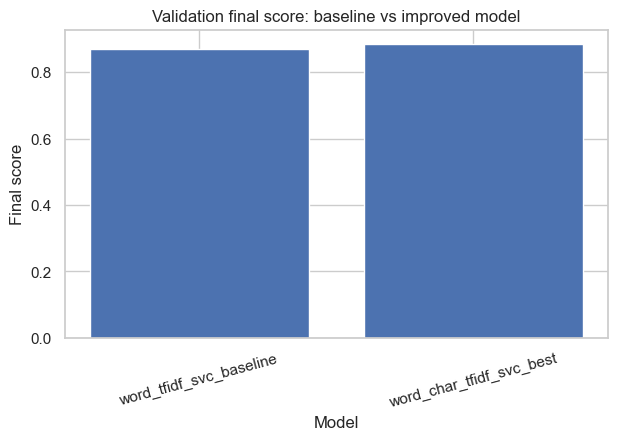

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(baseline_vs_best_val["model"], baseline_vs_best_val["final_score"])
plt.title("Validation final score: baseline vs improved model")
plt.xlabel("Model")
plt.ylabel("Final score")
plt.xticks(rotation=15)
plt.show()

Анализ ошибок показал, что основная трудность задачи связана не с редкими специализированными классами, а с крупными и семантически близкими support-классами.

Наиболее частые пары путаницы:

- `Product Support -> Technical Support`
- `IT Support -> Technical Support`
- `Technical Support -> Product Support`
- `Customer Service -> Technical Support`
- `Technical Support -> Customer Service`
- `Customer Service -> Product Support`

Это означает, что для задачи характерна не столько проблема long tail, сколько проблема **перекрывающихся operational classes**.

Объединение **word** и **character** TF-IDF-признаков оказалось лучшим решением по следующим причинам:

1. **Word n-grams** хорошо захватывают содержательные слова, устойчивые фразы и типичные ticket templates.
2. **Char n-grams** дополняют их, улавливая:
   - морфологические вариации,
   - смешение языков,
   - частичные совпадения формулировок,
   - вариации написания product/service terms.
3. Наиболее заметный выигрыш был получен на **английской части validation**, где исходный word-only baseline работал хуже.

Таким образом, char-признаки не заменили word-признаки, а усилили их в более сложных случаях.

Отдельная оценка по языкам показала, что качество на **немецких** и **английских** тикетах различается.

Изначально baseline заметно хуже работал на английской части.  
После перехода к модели **word + char TF-IDF + LinearSVC** качество на английском существенно выросло, что было одним из ключевых источников общего улучшения.

FULL TEST METRICS (train+val -> test)


,queue_acc,queue_macro_f1,priority_acc,type_acc,final_score
0,0.717662,0.92127,0.737575,0.904646,0.891222



COVERAGE / CONFIDENCE ANALYSIS


,coverage,n_auto,n_manual,min_conf_at_cut,auto_queue_acc,auto_queue_macro_f1,auto_priority_acc,auto_type_acc,auto_final_score,oracle_queue_acc,oracle_queue_macro_f1,oracle_priority_acc,oracle_type_acc,oracle_final_score
0,0.05,309,5868,0.250291,0.993528,0.987239,0.741100,0.877023,0.933786,0.999676,0.999937,0.987049,0.993848,0.997090
1,0.10,618,5559,0.182054,0.975728,0.975934,0.815534,0.904531,0.941164,0.997572,0.999567,0.981544,0.990448,0.995496
2,0.15,927,5250,0.156834,0.971953,0.982731,0.845739,0.918015,0.952475,0.995791,0.999239,0.976850,0.987696,0.994149
3,0.20,1235,4942,0.141457,0.961943,0.983177,0.849393,0.924696,0.954337,0.992391,0.998662,0.969888,0.984944,0.992288
4,0.25,1544,4633,0.130531,0.958549,0.984722,0.862047,0.930699,0.958217,0.989639,0.998250,0.965517,0.982678,0.991004
5,0.30,1853,4324,0.121435,0.954128,0.985541,0.866703,0.936319,0.960332,0.986239,0.997733,0.960013,0.980897,0.989549
6,0.35,2162,4015,0.112247,0.946809,0.982147,0.858002,0.933858,0.956282,0.981383,0.996629,0.950299,0.976850,0.986713
7,0.40,2471,3706,0.104677,0.938891,0.979887,0.857952,0.934844,0.954840,0.975554,0.995429,0.943176,0.973936,0.984367
8,0.45,2780,3397,0.098696,0.924820,0.976598,0.851079,0.932014,0.951082,0.966165,0.993486,0.932977,0.969403,0.980797
9,0.50,3088,3089,0.092580,0.909974,0.973621,0.844236,0.931023,0.947824,0.954994,0.991336,0.922130,0.965517,0.977082



70 / 30 example


,coverage,n_auto,n_manual,min_conf_at_cut,auto_queue_acc,auto_queue_macro_f1,auto_priority_acc,auto_type_acc,auto_final_score,oracle_queue_acc,oracle_queue_macro_f1,oracle_priority_acc,oracle_type_acc,oracle_final_score
13,0.7,4324,1853,0.070928,0.837882,0.954991,0.803423,0.925994,0.927906,0.886514,0.974537,0.862393,0.948195,0.953764



Preview of test predictions with confidences


,subject,body,queue,pred_queue,conf_queue,priority,pred_priority,conf_priority,type,pred_type,conf_type,joint_conf_min,joint_conf_mean,is_auto_70
0,Audio Hardware Detected,"Dear Customer Support Team,\n\nI am reaching out to request help with a problem I am facing on my PC. Recently, the audio hardware is no longer being recognized by the system. Despite several trou...",Technical Support,Technical Support,0.211367,low,low,0.351014,Problem,Problem,0.490005,0.211367,0.350795,True
1,Organizational Revision,"Dear Customer Support Team,\n\nI am reaching out to request an update on the structural details of our organization. The current records reflect information about the marketing agency, which has r...",General Inquiry,IT Support,0.044376,medium,low,0.513661,Change,Change,0.551003,0.044376,0.369680,False
2,Mängel im Incident-Response-Prozess,"Sehr geehrtes Support-Team,\n\nich hoffe, diese Nachricht erreicht Sie wohlbehalten. Ich möchte einige Bedenken hinsichtlich der aktuellen Effizienz des Incident-Response-Workflows äußern. Unser T...",IT Support,IT Support,0.049822,medium,high,0.354588,Problem,Unknown,0.386340,0.049822,0.263583,False
3,Anfrage zu Rechnungs- und Zahlungsinformationen,"Sehr geehrtes Kundendienstteam,\n\nich hoffe, diese Nachricht erreicht Sie wohlbehalten. Ich wende mich an Sie, um Unterstützung bei der Klärung einer kürzlich erhaltenen Rechnung zu bitten. Bei d...",Billing and Payments,Billing and Payments,0.468844,high,high,0.345646,Request,Request,0.346193,0.345646,0.386895,True
4,Occasional Disruptions Across Several Products Post-Update,"Dear Support Team,\n\nWe are currently facing sporadic disruptions impacting multiple products, which we believe may be related to a recent CI/CD pipeline update. This update might be affecting th...",IT Support,Technical Support,0.060123,medium,medium,0.470589,Incident,Incident,0.620306,0.060123,0.383673,False
5,Anfrage zu Investment-Strategie-Angeboten,"Sehr geehrter Kundendienst,\n\nich hoffe, diese Nachricht erreicht Sie wohlbehalten. Ich schreibe, um mich nach den verfügbaren Angeboten für Investment-Strategien auf Ihrer Plattform zu erkundige...",Product Support,Customer Service,0.058209,low,low,0.454288,Request,Request,0.714745,0.058209,0.409081,False
6,Rechnungserkundigung,"Sehr geehrter Kundenservice,\n\nich möchte umfassende Details zum Abrechnungsablauf meines Kontos erhalten. Besonders interessiert mich die einzelnen Phasen, einschließlich der Erstellung der Rech...",Billing and Payments,Billing and Payments,0.479620,medium,low,0.442791,Request,Request,0.559643,0.442791,0.494018,True
7,Critical Service Disruption in Telehealth,"Dear Customer Support,\n\nI am submitting a report regarding a major interruption currently impacting access to telehealth services. The disruption appears to originate from either a network malfu...",Service Outages and Maintenance,Service Outages and Maintenance,0.148496,medium,high,0.659864,Incident,Incident,0.817699,0.148496,0.542019,True
8,Immediate Attention Required: Platform Downtime Disrupting Device Connectivity,"Dear Customer Support Team,\n\nI am submitting a report concerning a critical outage in the platform services that is currently hindering device connectivity throughout operations. This issue has ...",Technical Support,Technical Support,0.216093,high,high,0.792189,Incident,Incident,0.916455,0.216093,0.641579,True
9,Invoice Discrepancy Concern,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am writing to draw attention to a billing irregularity observed on my account involving several devices. Over the previous bi...",Billing and Payments,Billing and Payments,0.537539,low,medium,0.386361,Problem,Problem,0.721674,0.386361,0.548525,True


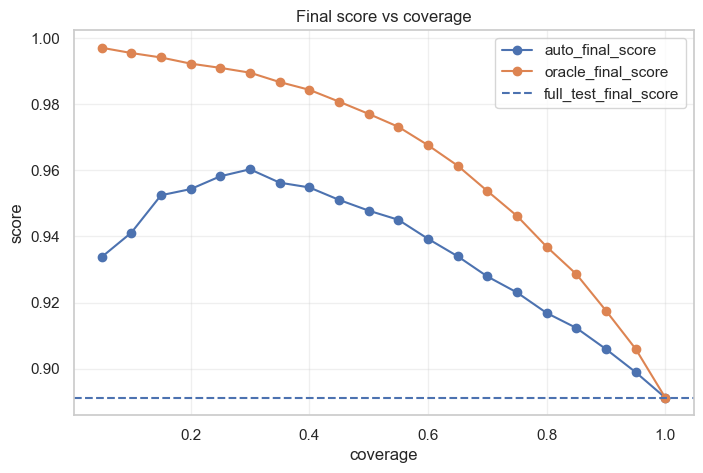

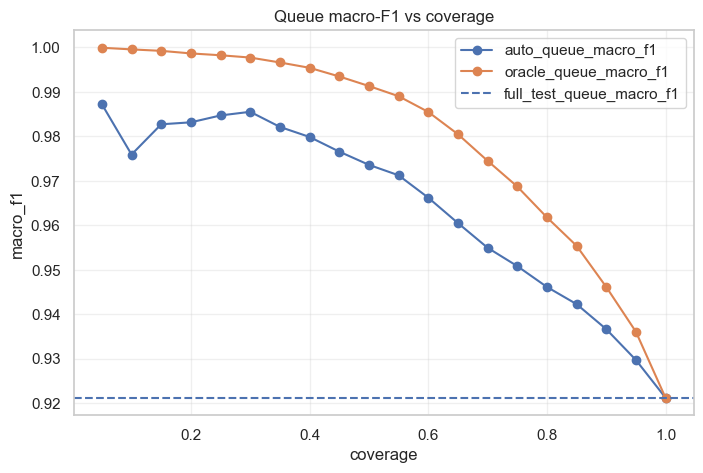

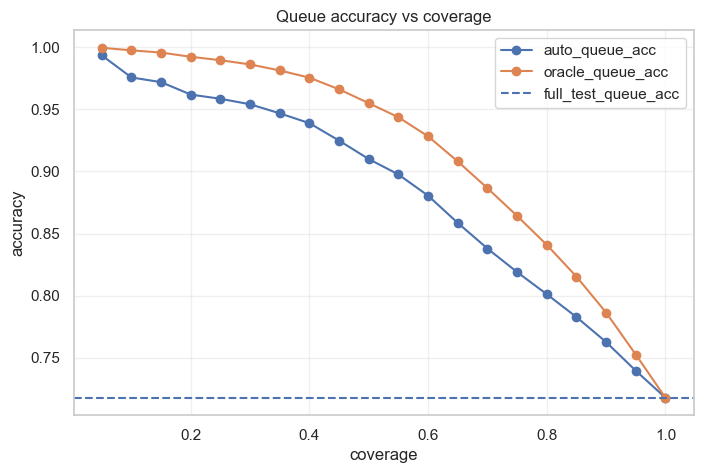

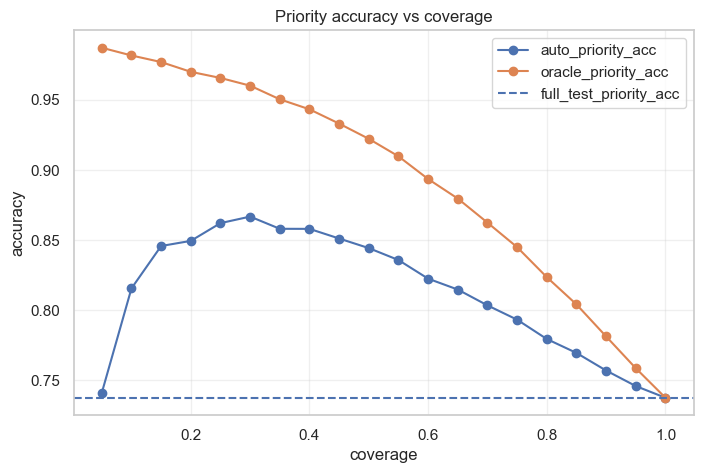

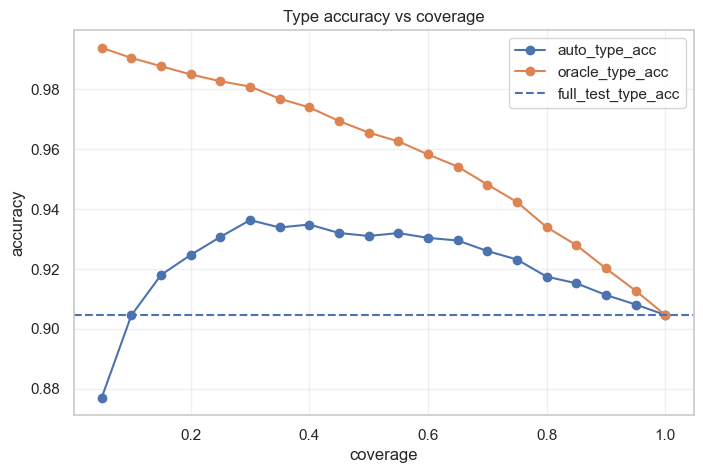

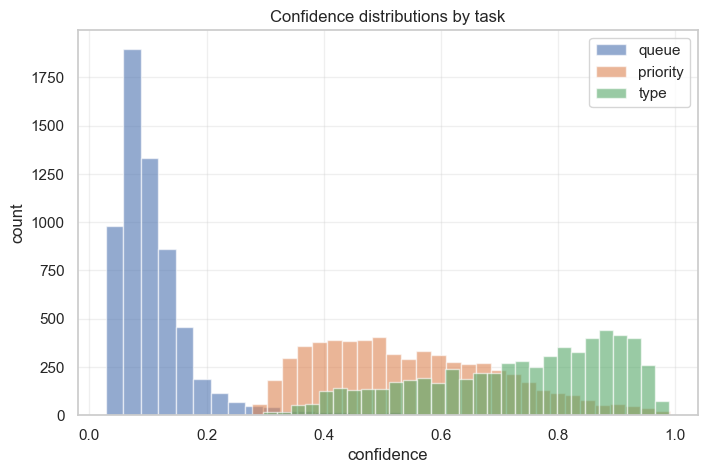

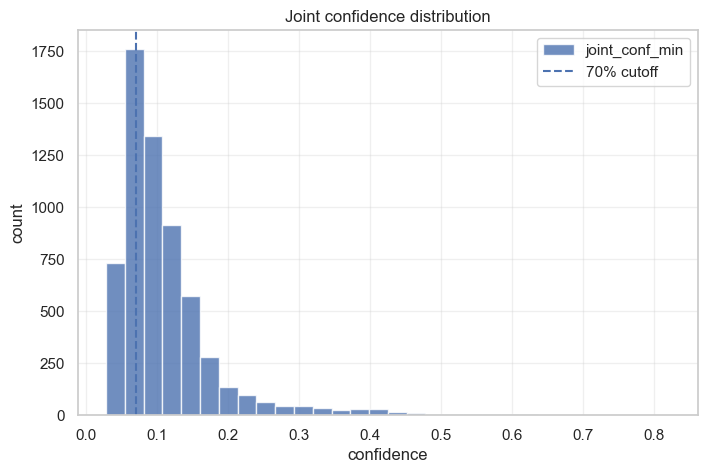

In [ ]:

def make_text_subject_body(df: pd.DataFrame, subject_repeat: int = 1) -> pd.Series:
    subject = df["subject"].fillna("").astype(str)
    body = df["body"].fillna("").astype(str)

    texts = []
    repeat = max(subject_repeat, 1)

    for s, b in zip(subject.tolist(), body.tolist()):
        s_block = "\n".join([s] * repeat)
        texts.append(s_block + "\n\n" + b)

    return pd.Series(texts, index=df.index)


def decision_to_confidence(clf, X):
    pred = clf.predict(X)
    dec = clf.decision_function(X)

    if dec.ndim == 2:
        probs = softmax(dec, axis=1)
        conf = probs.max(axis=1)
    else:
        p1 = expit(dec)
        conf = np.maximum(p1, 1.0 - p1)

    return pred, conf


def compute_final_score(queue_macro_f1, priority_acc, type_acc):
    return 0.70 * queue_macro_f1 + 0.15 * priority_acc + 0.15 * type_acc


def evaluate_all(yq_true, yq_pred, yp_true, yp_pred, yt_true, yt_pred):
    queue_acc = accuracy_score(yq_true, yq_pred)
    queue_macro_f1 = f1_score(yq_true, yq_pred, average="macro")
    priority_acc = accuracy_score(yp_true, yp_pred)
    type_acc = accuracy_score(yt_true, yt_pred)

    final_score = compute_final_score(
        queue_macro_f1=queue_macro_f1,
        priority_acc=priority_acc,
        type_acc=type_acc,
    )

    return {
        "queue_acc": queue_acc,
        "queue_macro_f1": queue_macro_f1,
        "priority_acc": priority_acc,
        "type_acc": type_acc,
        "final_score": final_score,
    }


train_df = trainval_df.copy()
test_df = splits["test"].copy()

train_df["type"] = train_df["type"].fillna("Unknown").astype(str)
test_df["type"] = test_df["type"].fillna("Unknown").astype(str)

word_min_df = BEST_PARAMS["word_min_df"]
char_ngram_range = BEST_PARAMS["char_ngram_range"]
C = BEST_PARAMS["C"]
subject_repeat = BEST_PARAMS["subject_repeat"]

X_train_text = make_text_subject_body(train_df, subject_repeat=subject_repeat)
X_test_text = make_text_subject_body(test_df, subject_repeat=subject_repeat)

word_vec = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1, 2),
    min_df=word_min_df,
)

char_vec = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=char_ngram_range,
    min_df=2,
    max_features=200_000,
)

Xtr_word = word_vec.fit_transform(X_train_text)
Xte_word = word_vec.transform(X_test_text)

Xtr_char = char_vec.fit_transform(X_train_text)
Xte_char = char_vec.transform(X_test_text)

Xtr = hstack([Xtr_word, Xtr_char]).tocsr()
Xte = hstack([Xte_word, Xte_char]).tocsr()

targets = ["queue", "priority", "type"]
models = {}
preds = {}
confs = {}

for target in targets:
    y_train = train_df[target].astype(str).values
    clf = LinearSVC(C=C)
    clf.fit(Xtr, y_train)

    pred, conf = decision_to_confidence(clf, Xte)

    models[target] = clf
    preds[target] = pred
    confs[target] = conf

yq_true = test_df["queue"].astype(str).values
yp_true = test_df["priority"].astype(str).values
yt_true = test_df["type"].astype(str).values

base_metrics = evaluate_all(
    yq_true, preds["queue"],
    yp_true, preds["priority"],
    yt_true, preds["type"],
)

print("FULL TEST METRICS (train+val -> test)")
display(pd.DataFrame([base_metrics]).round(6))

test_pred_df = test_df.copy().reset_index(drop=True)
test_pred_df["pred_queue"] = preds["queue"]
test_pred_df["pred_priority"] = preds["priority"]
test_pred_df["pred_type"] = preds["type"]

test_pred_df["conf_queue"] = confs["queue"]
test_pred_df["conf_priority"] = confs["priority"]
test_pred_df["conf_type"] = confs["type"]

test_pred_df["joint_conf_min"] = np.minimum.reduce([
    test_pred_df["conf_queue"].values,
    test_pred_df["conf_priority"].values,
    test_pred_df["conf_type"].values,
])

test_pred_df["joint_conf_mean"] = (
    test_pred_df[["conf_queue", "conf_priority", "conf_type"]].mean(axis=1)
)

order = np.argsort(-test_pred_df["joint_conf_min"].values)
n = len(test_pred_df)

rows = []
coverages = np.round(np.arange(0.05, 1.0001, 0.05), 2)

for cov in coverages:
    k = max(1, int(round(n * cov)))
    keep_idx = order[:k]
    review_idx = order[k:]

    auto_metrics = evaluate_all(
        yq_true[keep_idx], preds["queue"][keep_idx],
        yp_true[keep_idx], preds["priority"][keep_idx],
        yt_true[keep_idx], preds["type"][keep_idx],
    )

    q_oracle = preds["queue"].copy()
    p_oracle = preds["priority"].copy()
    t_oracle = preds["type"].copy()

    q_oracle[review_idx] = yq_true[review_idx]
    p_oracle[review_idx] = yp_true[review_idx]
    t_oracle[review_idx] = yt_true[review_idx]

    oracle_metrics = evaluate_all(
        yq_true, q_oracle,
        yp_true, p_oracle,
        yt_true, t_oracle,
    )

    rows.append({
        "coverage": cov,
        "n_auto": k,
        "n_manual": n - k,
        "min_conf_at_cut": float(test_pred_df["joint_conf_min"].values[order[k - 1]]),
        "auto_queue_acc": auto_metrics["queue_acc"],
        "auto_queue_macro_f1": auto_metrics["queue_macro_f1"],
        "auto_priority_acc": auto_metrics["priority_acc"],
        "auto_type_acc": auto_metrics["type_acc"],
        "auto_final_score": auto_metrics["final_score"],
        "oracle_queue_acc": oracle_metrics["queue_acc"],
        "oracle_queue_macro_f1": oracle_metrics["queue_macro_f1"],
        "oracle_priority_acc": oracle_metrics["priority_acc"],
        "oracle_type_acc": oracle_metrics["type_acc"],
        "oracle_final_score": oracle_metrics["final_score"],
    })

coverage_df = pd.DataFrame(rows)

print("\nCOVERAGE / CONFIDENCE ANALYSIS")
display(coverage_df.round(6))

print("\n70 / 30 example")
display(coverage_df.loc[np.isclose(coverage_df["coverage"], 0.70)].round(6))

test_pred_df["is_auto_70"] = False
k70 = max(1, int(round(n * 0.70)))
test_pred_df.loc[order[:k70], "is_auto_70"] = True

print("\nPreview of test predictions with confidences")
display(
    test_pred_df[
        [
            "subject", "body",
            "queue", "pred_queue", "conf_queue",
            "priority", "pred_priority", "conf_priority",
            "type", "pred_type", "conf_type",
            "joint_conf_min", "joint_conf_mean", "is_auto_70"
        ]
    ].head(10)
)

plt.figure(figsize=(8, 5))
plt.plot(coverage_df["coverage"], coverage_df["auto_final_score"], marker="o", label="auto_final_score")
plt.plot(coverage_df["coverage"], coverage_df["oracle_final_score"], marker="o", label="oracle_final_score")
plt.axhline(base_metrics["final_score"], linestyle="--", label="full_test_final_score")
plt.xlabel("coverage")
plt.ylabel("score")
plt.title("Final score vs coverage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(coverage_df["coverage"], coverage_df["auto_queue_macro_f1"], marker="o", label="auto_queue_macro_f1")
plt.plot(coverage_df["coverage"], coverage_df["oracle_queue_macro_f1"], marker="o", label="oracle_queue_macro_f1")
plt.axhline(base_metrics["queue_macro_f1"], linestyle="--", label="full_test_queue_macro_f1")
plt.xlabel("coverage")
plt.ylabel("macro_f1")
plt.title("Queue macro-F1 vs coverage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(coverage_df["coverage"], coverage_df["auto_queue_acc"], marker="o", label="auto_queue_acc")
plt.plot(coverage_df["coverage"], coverage_df["oracle_queue_acc"], marker="o", label="oracle_queue_acc")
plt.axhline(base_metrics["queue_acc"], linestyle="--", label="full_test_queue_acc")
plt.xlabel("coverage")
plt.ylabel("accuracy")
plt.title("Queue accuracy vs coverage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(coverage_df["coverage"], coverage_df["auto_priority_acc"], marker="o", label="auto_priority_acc")
plt.plot(coverage_df["coverage"], coverage_df["oracle_priority_acc"], marker="o", label="oracle_priority_acc")
plt.axhline(base_metrics["priority_acc"], linestyle="--", label="full_test_priority_acc")
plt.xlabel("coverage")
plt.ylabel("accuracy")
plt.title("Priority accuracy vs coverage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(coverage_df["coverage"], coverage_df["auto_type_acc"], marker="o", label="auto_type_acc")
plt.plot(coverage_df["coverage"], coverage_df["oracle_type_acc"], marker="o", label="oracle_type_acc")
plt.axhline(base_metrics["type_acc"], linestyle="--", label="full_test_type_acc")
plt.xlabel("coverage")
plt.ylabel("accuracy")
plt.title("Type accuracy vs coverage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(test_pred_df["conf_queue"], bins=30, alpha=0.6, label="queue")
plt.hist(test_pred_df["conf_priority"], bins=30, alpha=0.6, label="priority")
plt.hist(test_pred_df["conf_type"], bins=30, alpha=0.6, label="type")
plt.xlabel("confidence")
plt.ylabel("count")
plt.title("Confidence distributions by task")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(test_pred_df["joint_conf_min"], bins=30, alpha=0.8, label="joint_conf_min")
plt.axvline(
    coverage_df.loc[np.isclose(coverage_df["coverage"], 0.70), "min_conf_at_cut"].iloc[0],
    linestyle="--",
    label="70% cutoff"
)
plt.xlabel("confidence")
plt.ylabel("count")
plt.title("Joint confidence distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Анализ confidence-подхода показывает, что модель хорошо ранжирует предсказания по надежности и позволяет получить заметный практический эффект за счет selective automation. В полном автоматическом режиме на 100% тестовых тикетов модель дает queue accuracy = 0.7177, queue macro-F1 = 0.9213, priority accuracy = 0.7376, type accuracy = 0.9046, а итоговый final score = 0.8912. При этом если автоматически обрабатывать только 70% наиболее уверенных тикетов, качество на этой авто-доле существенно выше: queue accuracy = 0.8379, queue macro-F1 = 0.9550, priority accuracy = 0.8034, type accuracy = 0.9260, final score = 0.9279; то есть по сравнению с полным покрытием прирост на автоматически обработанной части составляет +12.0 п.п. по queue accuracy, +3.37 п.п. по queue macro-F1 и +3.67 п.п. по final score. Если же оставшиеся 30% низкоуверенных тикетов передавать на ручную разметку, то в гибридном сценарии итоговое качество всей системы возрастает до oracle queue accuracy = 0.8865, oracle queue macro-F1 = 0.9745, oracle priority accuracy = 0.8624, oracle type accuracy = 0.9482, oracle final score = 0.9538, что означает выигрыш относительно полного автомата на +16.9 п.п. по queue accuracy, +5.33 п.п. по queue macro-F1 и +6.25 п.п. по final score. Эффект монотонный: чем меньшую долю тикетов модель берет в автомат, тем выше качество — например, уже при 50/50 итоговый oracle final score = 0.9771, а при 30/70 достигает 0.9895. Таким образом, confidence можно использовать как рабочий инструмент управления балансом между покрытием и качеством: модель уверенно автоматизирует наиболее простые обращения, а сложный хвост целесообразно отправлять на ручную маршрутизацию ради существенного прироста бизнес-качества.

# TRANSFORMER

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_NAME = "Tobi-Bueck/customer-support-tickets"
MODEL_NAME = "microsoft/mdeberta-v3-base"

MAX_LENGTH = 224
BATCH_SIZE = 64
NUM_EPOCHS = 15
RANDOM_STATE = 42

TARGETS = ["queue", "priority", "type"]

QUEUE_LOSS_WEIGHT = 0.80
PRIORITY_LOSS_WEIGHT = 0.1
TYPE_LOSS_WEIGHT = 0.1

BEST_METRIC_NAME = "final_score"

NUM_WORKERS = 0
PIN_MEMORY = DEVICE.type == "cuda"

USE_CUSTOM_SPLITS = True
INDEX_DIR = Path("data")   

OUTPUT_DIR = Path("outputs_mdeberta_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PATH = OUTPUT_DIR / "best_mdeberta_multitask.pt"
HISTORY_PATH = OUTPUT_DIR / "history.csv"

USE_AMP = DEVICE.type == "cuda"
if USE_AMP and torch.cuda.is_bf16_supported():
    AMP_DTYPE = torch.bfloat16
else:
    AMP_DTYPE = torch.float16

USE_SCALER = USE_AMP and AMP_DTYPE == torch.float16
SCALER = torch.amp.GradScaler("cuda", enabled=USE_SCALER) if DEVICE.type == "cuda" else None

NUM_UNFROZEN_LAYERS = 6

HEAD_DROPOUT = 0.20
HEAD_HIDDEN_MULTIPLIER = 1.0

ENCODER_LR = 3e-5
HEAD_LR = 2e-4
ENCODER_WEIGHT_DECAY = 0.01
HEAD_WEIGHT_DECAY = 0.02
MAX_GRAD_NORM = 1.0


QUEUE_LABEL_SMOOTHING = 0
PRIORITY_LABEL_SMOOTHING = 0
TYPE_LABEL_SMOOTHING = 0


WARMUP_RATIO = 0.10

EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 1e-4


TOP_K_WORST_CLASSES = 10
TOP_K_ERRORS = 20
PLOT_NORMALIZED_CM = True

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)


def autocast_context():
    if DEVICE.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP)
    return nullcontext()

def read_idx(path: Path):
    return np.array(
        [int(line.strip()) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()],
        dtype=np.int64,
    )


def split_df(
    df: pd.DataFrame,
    use_custom_splits: bool = True,
    index_dir: Path = Path("data"),
) -> Dict[str, pd.DataFrame]:
    train_path = index_dir / "train_idx.txt"
    val_path = index_dir / "val_idx.txt"
    test_path = index_dir / "test_idx.txt"

    if use_custom_splits and train_path.exists() and val_path.exists() and test_path.exists():
        train_idx = read_idx(train_path)
        val_idx = read_idx(val_path)
        test_idx = read_idx(test_path)

        return {
            "train": df.iloc[train_idx].reset_index(drop=True).copy(),
            "val": df.iloc[val_idx].reset_index(drop=True).copy(),
            "test": df.iloc[test_idx].reset_index(drop=True).copy(),
        }

    raise FileNotFoundError(
        f"Не найдены файлы индексов в папке {index_dir.resolve()}.\n"
        f"Ожидаю:\n"
        f"- {train_path}\n"
        f"- {val_path}\n"
        f"- {test_path}"
    )


def build_input_text(df: pd.DataFrame) -> pd.Series:
    subject = df["subject"].fillna("").astype(str)
    body = df["body"].fillna("").astype(str)
    language = df["language"].fillna("").astype(str)

    data = (
        "language: " + language
        + "\n\nsubject: " + subject
        + "\n\nbody: " + body
    )
    return data


def build_label_maps(train_df: pd.DataFrame, target: str) -> Tuple[Dict[str, int], Dict[int, str]]:
    labels = sorted(train_df[target].astype(str).unique().tolist())
    label2id = {label: idx for idx, label in enumerate(labels)}
    id2label = {idx: label for label, idx in label2id.items()}
    return label2id, id2label


def apply_label_map(df: pd.DataFrame, target: str, label2id: Dict[str, int]) -> pd.DataFrame:
    df = df.copy()
    values = df[target].astype(str)

    unseen = sorted(set(values.unique()) - set(label2id.keys()))
    if unseen:
        raise ValueError(f"Unseen labels in target={target}: {unseen}")

    df[f"{target}_id"] = values.map(label2id).astype(int)
    return df


def prepare_splits() -> tuple[
    Dict[str, pd.DataFrame],
    Dict[str, Dict[str, int]],
    Dict[str, Dict[int, str]],
]:
    ds = load_dataset(DATASET_NAME)["train"]
    df = ds.to_pandas()

    needed = {"subject", "body", "queue", "priority", "type", "language"}
    missing = sorted(list(needed - set(df.columns)))
    if missing:
        raise ValueError(f"Dataset missing columns: {missing}")

    splits = split_df(
        df=df,
        use_custom_splits=USE_CUSTOM_SPLITS,
        index_dir=INDEX_DIR,
    )

    for split_name in splits:
        splits[split_name]["type"] = splits[split_name]["type"].fillna("Unknown")
        splits[split_name]["input_text"] = build_input_text(splits[split_name])

    label2id_all: Dict[str, Dict[str, int]] = {}
    id2label_all: Dict[str, Dict[int, str]] = {}

    for target in TARGETS:
        label2id, id2label = build_label_maps(splits["train"], target)
        label2id_all[target] = label2id
        id2label_all[target] = id2label

        for split_name in splits:
            splits[split_name] = apply_label_map(splits[split_name], target, label2id)

    return splits, label2id_all, id2label_all


def load_tokenizer():
    return AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

In [4]:
class TicketDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int):
        self.queue_ids = df["queue_id"].tolist()
        self.priority_ids = df["priority_id"].tolist()
        self.type_ids = df["type_id"].tolist()

        self.encodings = tokenizer(
            df["input_text"].tolist(),
            truncation=True,
            max_length=max_length,
            padding=False,
        )

    def __len__(self) -> int:
        return len(self.queue_ids)

    def __getitem__(self, idx: int):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels_queue": self.queue_ids[idx],
            "labels_priority": self.priority_ids[idx],
            "labels_type": self.type_ids[idx],
        }


class MultitaskCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        input_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"],
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            input_features,
            padding=True,
            return_tensors="pt",
        )

        batch["labels_queue"] = torch.tensor([f["labels_queue"] for f in features], dtype=torch.long)
        batch["labels_priority"] = torch.tensor([f["labels_priority"] for f in features], dtype=torch.long)
        batch["labels_type"] = torch.tensor([f["labels_type"] for f in features], dtype=torch.long)

        return batch


def build_dataloaders(splits: Dict[str, pd.DataFrame], tokenizer):
    collator = MultitaskCollator(tokenizer)

    train_dataset = TicketDataset(splits["train"], tokenizer, MAX_LENGTH)
    val_dataset = TicketDataset(splits["val"], tokenizer, MAX_LENGTH)
    test_dataset = TicketDataset(splits["test"], tokenizer, MAX_LENGTH)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=PIN_MEMORY,
        collate_fn=collator,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=PIN_MEMORY,
        collate_fn=collator,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=PIN_MEMORY,
        collate_fn=collator,
    )

    return train_loader, val_loader, test_loader

In [5]:
class MultitaskDebertaClassifier(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_queue_labels: int,
        num_priority_labels: int,
        num_type_labels: int,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        pooled_size = hidden_size * 3
        head_hidden = int(hidden_size * HEAD_HIDDEN_MULTIPLIER)

        self.dropout = nn.Dropout(dropout)

        self.shared_proj = nn.Sequential(
            nn.Linear(pooled_size, head_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.queue_head = nn.Linear(head_hidden, num_queue_labels)
        self.priority_head = nn.Linear(head_hidden, num_priority_labels)
        self.type_head = nn.Linear(head_hidden, num_type_labels)

    @staticmethod
    def masked_mean_pooling(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)
        masked_hidden = last_hidden_state * mask
        summed = masked_hidden.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-6)
        return summed / counts

    @staticmethod
    def masked_max_pooling(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        mask = attention_mask.unsqueeze(-1).bool()
        masked_hidden = last_hidden_state.masked_fill(~mask, float("-inf"))
        max_pooled = masked_hidden.max(dim=1).values

        inf_mask = torch.isinf(max_pooled)
        if inf_mask.any():
            max_pooled = torch.where(inf_mask, torch.zeros_like(max_pooled), max_pooled)

        return max_pooled

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels_queue: Optional[torch.Tensor] = None,
        labels_priority: Optional[torch.Tensor] = None,
        labels_type: Optional[torch.Tensor] = None,
    ):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        last_hidden_state = outputs.last_hidden_state

        cls_pool = last_hidden_state[:, 0]
        mean_pool = self.masked_mean_pooling(last_hidden_state, attention_mask)
        max_pool = self.masked_max_pooling(last_hidden_state, attention_mask)

        pooled = torch.cat([cls_pool, mean_pool, max_pool], dim=-1)
        pooled = self.dropout(pooled)
        features = self.shared_proj(pooled)

        logits_queue = self.queue_head(features)
        logits_priority = self.priority_head(features)
        logits_type = self.type_head(features)

        out = {
            "logits_queue": logits_queue,
            "logits_priority": logits_priority,
            "logits_type": logits_type,
        }

        if labels_queue is not None and labels_priority is not None and labels_type is not None:
            loss_queue = F.cross_entropy(
                logits_queue,
                labels_queue,
                label_smoothing=QUEUE_LABEL_SMOOTHING,
            )
            loss_priority = F.cross_entropy(
                logits_priority,
                labels_priority,
                label_smoothing=PRIORITY_LABEL_SMOOTHING,
            )
            loss_type = F.cross_entropy(
                logits_type,
                labels_type,
                label_smoothing=TYPE_LABEL_SMOOTHING,
            )

            loss = (
                QUEUE_LOSS_WEIGHT * loss_queue
                + PRIORITY_LOSS_WEIGHT * loss_priority
                + TYPE_LOSS_WEIGHT * loss_type
            )

            out["loss"] = loss
            out["loss_queue"] = loss_queue
            out["loss_priority"] = loss_priority
            out["loss_type"] = loss_type

        return out


def build_model(label2id_all: Dict[str, Dict[str, int]]) -> nn.Module:
    return MultitaskDebertaClassifier(
        model_name=MODEL_NAME,
        num_queue_labels=len(label2id_all["queue"]),
        num_priority_labels=len(label2id_all["priority"]),
        num_type_labels=len(label2id_all["type"]),
        dropout=HEAD_DROPOUT,
    )

def get_encoder_layers(model: nn.Module) -> List[nn.Module]:
    if hasattr(model.encoder, "encoder") and hasattr(model.encoder.encoder, "layer"):
        return list(model.encoder.encoder.layer)
    if hasattr(model.encoder, "layer"):
        return list(model.encoder.layer)
    raise ValueError("Не удалось найти encoder layers в модели.")


def freeze_encoder_except_last_n(model: nn.Module, num_unfrozen_layers: int):
    for param in model.encoder.parameters():
        param.requires_grad = False

    layers = get_encoder_layers(model)
    total_layers = len(layers)

    if num_unfrozen_layers < 0:
        raise ValueError("NUM_UNFROZEN_LAYERS must be >= 0")

    n = min(num_unfrozen_layers, total_layers)

    if n > 0:
        for layer in layers[-n:]:
            for param in layer.parameters():
                param.requires_grad = True

    if n == total_layers:
        for param in model.encoder.parameters():
            param.requires_grad = True

    for module in [model.shared_proj, model.queue_head, model.priority_head, model.type_head]:
        for param in module.parameters():
            param.requires_grad = True


def print_trainable_parameters(model: nn.Module):
    total_params = 0
    trainable_params = 0
    for name, param in model.named_parameters():
        total_params += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()


    print(f"\nTotal params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    print(f"Frozen params: {total_params - trainable_params:,}")
    print(f"Trainable %: {100 * trainable_params / total_params:.2f}%")


In [6]:


def compute_metrics_from_predictions(
    y_queue_true,
    y_queue_pred,
    y_priority_true,
    y_priority_pred,
    y_type_true,
    y_type_pred,
) -> dict:
    queue_acc = accuracy_score(y_queue_true, y_queue_pred)
    queue_macro_f1 = f1_score(y_queue_true, y_queue_pred, average="macro")

    priority_acc = accuracy_score(y_priority_true, y_priority_pred)
    type_acc = accuracy_score(y_type_true, y_type_pred)

    final_score = (
        0.70 * queue_macro_f1
        + 0.15 * priority_acc
        + 0.15 * type_acc
    )

    return {
        "queue_acc": float(queue_acc),
        "queue_macro_f1": float(queue_macro_f1),
        "priority_acc": float(priority_acc),
        "type_acc": float(type_acc),
        "final_score": float(final_score),
    }


def plot_training_history(history_df: pd.DataFrame):
    clear_output(wait=True)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["eval_loss"], marker="o", label="val_loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history_df["epoch"], history_df["train_queue_macro_f1"], marker="o", label="train")
    axes[1].plot(history_df["epoch"], history_df["queue_macro_f1"], marker="o", label="val")
    axes[1].set_title("Queue Macro F1")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(history_df["epoch"], history_df["train_priority_acc"], marker="o", label="train")
    axes[2].plot(history_df["epoch"], history_df["priority_acc"], marker="o", label="val")
    axes[2].set_title("Priority Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(history_df["epoch"], history_df["train_type_acc"], marker="o", label="train")
    axes[3].plot(history_df["epoch"], history_df["type_acc"], marker="o", label="val")
    axes[3].set_title("Type Accuracy")
    axes[3].set_xlabel("Epoch")
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    axes[4].plot(history_df["epoch"], history_df["train_final_score"], marker="o", label="train")
    axes[4].plot(history_df["epoch"], history_df["final_score"], marker="o", label="val")
    axes[4].set_title("Final Score")
    axes[4].set_xlabel("Epoch")
    axes[4].legend()
    axes[4].grid(True, alpha=0.3)

    if "lr_head" in history_df.columns:
        axes[5].plot(history_df["epoch"], history_df["lr_encoder"], marker="o", label="lr_encoder")
        axes[5].plot(history_df["epoch"], history_df["lr_head"], marker="o", label="lr_head")
        axes[5].set_title("Learning Rates")
        axes[5].set_xlabel("Epoch")
        axes[5].legend()
        axes[5].grid(True, alpha=0.3)
    else:
        axes[5].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    display(history_df.round(4))

In [7]:


def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            if device.type == "cuda":
                out[k] = v.to(device, non_blocking=True)
            else:
                out[k] = v.to(device)
        else:
            out[k] = v
    return out


def get_parameter_groups(model: nn.Module):
    no_decay_keywords = [
        "bias",
        "LayerNorm.weight",
        "LayerNorm.bias",
        "layer_norm.weight",
        "layer_norm.bias",
        "norm.weight",
        "norm.bias",
    ]

    encoder_decay = []
    encoder_no_decay = []
    head_decay = []
    head_no_decay = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        is_no_decay = any(nd in name for nd in no_decay_keywords)
        is_encoder = name.startswith("encoder.")

        if is_encoder:
            if is_no_decay:
                encoder_no_decay.append(param)
            else:
                encoder_decay.append(param)
        else:
            if is_no_decay:
                head_no_decay.append(param)
            else:
                head_decay.append(param)

    param_groups = []

    if encoder_decay:
        param_groups.append({
            "params": encoder_decay,
            "lr": ENCODER_LR,
            "weight_decay": ENCODER_WEIGHT_DECAY,
            "group_name": "encoder_decay",
        })
    if encoder_no_decay:
        param_groups.append({
            "params": encoder_no_decay,
            "lr": ENCODER_LR,
            "weight_decay": 0.0,
            "group_name": "encoder_no_decay",
        })
    if head_decay:
        param_groups.append({
            "params": head_decay,
            "lr": HEAD_LR,
            "weight_decay": HEAD_WEIGHT_DECAY,
            "group_name": "head_decay",
        })
    if head_no_decay:
        param_groups.append({
            "params": head_no_decay,
            "lr": HEAD_LR,
            "weight_decay": 0.0,
            "group_name": "head_no_decay",
        })

    return param_groups


def print_optimizer_groups(optimizer):
    print("\n===== OPTIMIZER PARAM GROUPS =====")
    for i, group in enumerate(optimizer.param_groups):
        n_params = sum(p.numel() for p in group["params"])
        print(
            f"group={i} | "
            f"name={group.get('group_name', 'n/a')} | "
            f"lr={group['lr']:.2e} | "
            f"wd={group['weight_decay']:.4f} | "
            f"params={n_params:,}"
        )


def train_one_epoch(model, loader, optimizer, scheduler, device, epoch=None, num_epochs=None):
    model.train()

    total_loss = 0.0
    total_loss_queue = 0.0
    total_loss_priority = 0.0
    total_loss_type = 0.0

    y_queue_true, y_queue_pred = [], []
    y_priority_true, y_priority_pred = [], []
    y_type_true, y_type_pred = [], []

    train_desc = f"Train Epoch {epoch}/{num_epochs}" if epoch is not None and num_epochs is not None else "Train"
    progress_bar = tqdm(loader, desc=train_desc, leave=True)

    for batch in progress_bar:
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels_queue=batch["labels_queue"],
                labels_priority=batch["labels_priority"],
                labels_type=batch["labels_type"],
            )
            loss = out["loss"]

        if USE_SCALER:
            SCALER.scale(loss).backward()
            SCALER.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
            SCALER.step(optimizer)
            SCALER.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
            optimizer.step()

        scheduler.step()

        total_loss += float(loss.item())
        total_loss_queue += float(out["loss_queue"].item())
        total_loss_priority += float(out["loss_priority"].item())
        total_loss_type += float(out["loss_type"].item())

        pred_queue = out["logits_queue"].argmax(dim=1)
        pred_priority = out["logits_priority"].argmax(dim=1)
        pred_type = out["logits_type"].argmax(dim=1)

        y_queue_true.extend(batch["labels_queue"].detach().cpu().tolist())
        y_queue_pred.extend(pred_queue.detach().cpu().tolist())

        y_priority_true.extend(batch["labels_priority"].detach().cpu().tolist())
        y_priority_pred.extend(pred_priority.detach().cpu().tolist())

        y_type_true.extend(batch["labels_type"].detach().cpu().tolist())
        y_type_pred.extend(pred_type.detach().cpu().tolist())

        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    n_batches = max(len(loader), 1)

    metrics = compute_metrics_from_predictions(
        y_queue_true=y_queue_true,
        y_queue_pred=y_queue_pred,
        y_priority_true=y_priority_true,
        y_priority_pred=y_priority_pred,
        y_type_true=y_type_true,
        y_type_pred=y_type_pred,
    )

    metrics = {
        "train_loss": total_loss / n_batches,
        "train_loss_queue": total_loss_queue / n_batches,
        "train_loss_priority": total_loss_priority / n_batches,
        "train_loss_type": total_loss_type / n_batches,
        "train_queue_acc": metrics["queue_acc"],
        "train_queue_macro_f1": metrics["queue_macro_f1"],
        "train_priority_acc": metrics["priority_acc"],
        "train_type_acc": metrics["type_acc"],
        "train_final_score": metrics["final_score"],
    }

    return metrics


@torch.no_grad()
def evaluate(model, loader, device, epoch=None, num_epochs=None):
    model.eval()

    total_loss = 0.0
    total_loss_queue = 0.0
    total_loss_priority = 0.0
    total_loss_type = 0.0

    y_queue_true, y_queue_pred = [], []
    y_priority_true, y_priority_pred = [], []
    y_type_true, y_type_pred = [], []

    eval_desc = f"Eval Epoch {epoch}/{num_epochs}" if epoch is not None and num_epochs is not None else "Eval"
    progress_bar = tqdm(loader, desc=eval_desc, leave=True)

    for batch in progress_bar:
        batch = move_batch_to_device(batch, device)

        with autocast_context():
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels_queue=batch["labels_queue"],
                labels_priority=batch["labels_priority"],
                labels_type=batch["labels_type"],
            )

        total_loss += float(out["loss"].item())
        total_loss_queue += float(out["loss_queue"].item())
        total_loss_priority += float(out["loss_priority"].item())
        total_loss_type += float(out["loss_type"].item())

        pred_queue = out["logits_queue"].argmax(dim=1)
        pred_priority = out["logits_priority"].argmax(dim=1)
        pred_type = out["logits_type"].argmax(dim=1)

        y_queue_true.extend(batch["labels_queue"].detach().cpu().tolist())
        y_queue_pred.extend(pred_queue.detach().cpu().tolist())

        y_priority_true.extend(batch["labels_priority"].detach().cpu().tolist())
        y_priority_pred.extend(pred_priority.detach().cpu().tolist())

        y_type_true.extend(batch["labels_type"].detach().cpu().tolist())
        y_type_pred.extend(pred_type.detach().cpu().tolist())

        progress_bar.set_postfix({"loss": f"{out['loss'].item():.4f}"})

    n_batches = max(len(loader), 1)

    metrics = compute_metrics_from_predictions(
        y_queue_true=y_queue_true,
        y_queue_pred=y_queue_pred,
        y_priority_true=y_priority_true,
        y_priority_pred=y_priority_pred,
        y_type_true=y_type_true,
        y_type_pred=y_type_pred,
    )

    metrics.update({
        "eval_loss": total_loss / n_batches,
        "eval_loss_queue": total_loss_queue / n_batches,
        "eval_loss_priority": total_loss_priority / n_batches,
        "eval_loss_type": total_loss_type / n_batches,
    })

    return metrics


@torch.no_grad()
def predict_with_details(model, loader, device):
    model.eval()

    rows = []

    for batch in tqdm(loader, desc="Predict", leave=True):
        batch = move_batch_to_device(batch, device)

        with autocast_context():
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels_queue=batch["labels_queue"],
                labels_priority=batch["labels_priority"],
                labels_type=batch["labels_type"],
            )

        probs_queue = torch.softmax(out["logits_queue"], dim=1)
        probs_priority = torch.softmax(out["logits_priority"], dim=1)
        probs_type = torch.softmax(out["logits_type"], dim=1)

        pred_queue = out["logits_queue"].argmax(dim=1)
        pred_priority = out["logits_priority"].argmax(dim=1)
        pred_type = out["logits_type"].argmax(dim=1)

        k = min(2, probs_queue.shape[1])
        topk_vals, topk_idx = probs_queue.topk(k=k, dim=1)

        for i in range(batch["input_ids"].size(0)):
            top1 = float(topk_vals[i, 0].detach().cpu().item())
            top2 = float(topk_vals[i, 1].detach().cpu().item()) if k > 1 else 0.0

            rows.append({
                "queue_true_id": int(batch["labels_queue"][i].detach().cpu().item()),
                "queue_pred_id": int(pred_queue[i].detach().cpu().item()),
                "priority_true_id": int(batch["labels_priority"][i].detach().cpu().item()),
                "priority_pred_id": int(pred_priority[i].detach().cpu().item()),
                "type_true_id": int(batch["labels_type"][i].detach().cpu().item()),
                "type_pred_id": int(pred_type[i].detach().cpu().item()),
                "queue_confidence": top1,
                "queue_second_confidence": top2,
                "queue_margin": top1 - top2,
                "priority_confidence": float(probs_priority[i].max().detach().cpu().item()),
                "type_confidence": float(probs_type[i].max().detach().cpu().item()),
            })

    return pd.DataFrame(rows)

In [8]:
def queue_diagnostics(
    details_df: pd.DataFrame,
    original_df: pd.DataFrame,
    id2label_all: Dict[str, Dict[int, str]],
    output_dir: Path | None = None,
    top_k_worst_classes: int = 10,
    top_k_errors: int = 20,
    plot_normalized_cm: bool = True,
):
    original_df = original_df.reset_index(drop=True).copy()
    details_df = details_df.reset_index(drop=True).copy()

    if len(details_df) != len(original_df):
        raise ValueError(f"Length mismatch: details_df={len(details_df)} vs original_df={len(original_df)}")

    details_df["queue_true"] = details_df["queue_true_id"].map(id2label_all["queue"])
    details_df["queue_pred"] = details_df["queue_pred_id"].map(id2label_all["queue"])
    details_df["priority_true"] = details_df["priority_true_id"].map(id2label_all["priority"])
    details_df["priority_pred"] = details_df["priority_pred_id"].map(id2label_all["priority"])
    details_df["type_true"] = details_df["type_true_id"].map(id2label_all["type"])
    details_df["type_pred"] = details_df["type_pred_id"].map(id2label_all["type"])

    result_df = pd.concat([original_df.reset_index(drop=True), details_df], axis=1)

    result_df["queue_correct"] = result_df["queue_true_id"] == result_df["queue_pred_id"]
    result_df["priority_correct"] = result_df["priority_true_id"] == result_df["priority_pred_id"]
    result_df["type_correct"] = result_df["type_true_id"] == result_df["type_pred_id"]

    queue_labels_sorted = [id2label_all["queue"][i] for i in sorted(id2label_all["queue"].keys())]

    report_dict = classification_report(
        result_df["queue_true"],
        result_df["queue_pred"],
        labels=queue_labels_sorted,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T

    print("\n===== QUEUE CLASSIFICATION REPORT =====")
    display(report_df.round(4))

    class_rows = [x for x in queue_labels_sorted if x in report_df.index]
    worst_df = (
        report_df.loc[class_rows, ["precision", "recall", "f1-score", "support"]]
        .sort_values(["f1-score", "support"], ascending=[True, False])
        .head(top_k_worst_classes)
        .copy()
    )

    print(f"\n===== TOP-{top_k_worst_classes} WORST QUEUE CLASSES BY F1 =====")
    display(worst_df.round(4))

    cm = confusion_matrix(
        result_df["queue_true"],
        result_df["queue_pred"],
        labels=queue_labels_sorted,
        normalize="true" if plot_normalized_cm else None,
    )

    fig_size = max(16, int(len(queue_labels_sorted) * 0.35))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=queue_labels_sorted,
    )
    disp.plot(
        ax=ax,
        xticks_rotation=90,
        values_format=".2f" if plot_normalized_cm else "d",
        colorbar=False,
    )
    title_suffix = "Normalized" if plot_normalized_cm else "Raw"
    ax.set_title(f"Queue Confusion Matrix ({title_suffix})")
    plt.tight_layout()
    plt.show()

    queue_errors_df = (
        result_df.loc[~result_df["queue_correct"]].copy()
        .sort_values(["queue_confidence", "queue_margin"], ascending=[False, False])
    )

    error_cols = [
        "language",
        "subject",
        "body",
        "queue_true",
        "queue_pred",
        "queue_confidence",
        "queue_margin",
        "priority_true",
        "priority_pred",
        "type_true",
        "type_pred",
    ]

    print(f"\n===== TOP-{top_k_errors} MOST CONFIDENT QUEUE ERRORS =====")
    display(queue_errors_df[error_cols].head(top_k_errors))

    pair_df = (
        result_df.loc[~result_df["queue_correct"], ["queue_true", "queue_pred"]]
        .value_counts()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    print("\n===== TOP CONFUSION PAIRS (QUEUE) =====")
    display(pair_df.head(20))

    if output_dir is not None:
        output_dir.mkdir(parents=True, exist_ok=True)

        report_df.to_csv(output_dir / "queue_classification_report.csv")
        worst_df.to_csv(output_dir / "queue_worst_classes.csv")
        queue_errors_df.to_csv(output_dir / "queue_errors_full.csv", index=False)
        pair_df.to_csv(output_dir / "queue_confusion_pairs.csv", index=False)
        result_df.to_csv(output_dir / "test_predictions_full.csv", index=False)

        print("\nSaved:")
        print(output_dir / "queue_classification_report.csv")
        print(output_dir / "queue_worst_classes.csv")
        print(output_dir / "queue_errors_full.csv")
        print(output_dir / "queue_confusion_pairs.csv")
        print(output_dir / "test_predictions_full.csv")

    return {
        "result_df": result_df,
        "report_df": report_df,
        "worst_df": worst_df,
        "queue_errors_df": queue_errors_df,
        "pair_df": pair_df,
    }


def save_checkpoint(model, save_path: Path, label2id_all, id2label_all, history_df: Optional[pd.DataFrame] = None):
    payload = {
        "model_state_dict": model.state_dict(),
        "label2id_all": label2id_all,
        "id2label_all": id2label_all,
        "model_name": MODEL_NAME,
        "max_length": MAX_LENGTH,
        "num_unfrozen_layers": NUM_UNFROZEN_LAYERS,
        "config": {
            "encoder_lr": ENCODER_LR,
            "head_lr": HEAD_LR,
            "encoder_weight_decay": ENCODER_WEIGHT_DECAY,
            "head_weight_decay": HEAD_WEIGHT_DECAY,
            "queue_label_smoothing": QUEUE_LABEL_SMOOTHING,
            "priority_label_smoothing": PRIORITY_LABEL_SMOOTHING,
            "type_label_smoothing": TYPE_LABEL_SMOOTHING,
            "head_dropout": HEAD_DROPOUT,
        }
    }
    torch.save(payload, save_path)

    if history_df is not None:
        history_df.to_csv(HISTORY_PATH, index=False)


def main():
    tokenizer = load_tokenizer()
    splits, label2id_all, id2label_all = prepare_splits()

    print("\nModel:", MODEL_NAME)
    print("Tokenizer:", tokenizer.__class__.__name__)
    print("Device:", DEVICE)
    print(f"AMP enabled: {USE_AMP} | dtype: {AMP_DTYPE}")
    print(f"NUM_UNFROZEN_LAYERS: {NUM_UNFROZEN_LAYERS}")
    print()


    train_loader, val_loader, test_loader = build_dataloaders(splits, tokenizer)

    model = build_model(label2id_all)
    freeze_encoder_except_last_n(model, NUM_UNFROZEN_LAYERS)
    model.to(DEVICE)
    print_trainable_parameters(model)
    
    optimizer = torch.optim.AdamW(get_parameter_groups(model))
    

    total_training_steps = len(train_loader) * NUM_EPOCHS
    warmup_steps = int(WARMUP_RATIO * total_training_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_training_steps,
    )

    best_metric = -1e9
    history = []
    patience_counter = 0

    print("\nStarting training...")

    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\n===== Epoch {epoch}/{NUM_EPOCHS} =====")
        epoch_start = time.time()

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            device=DEVICE,
            epoch=epoch,
            num_epochs=NUM_EPOCHS,
        )

        val_metrics = evaluate(
            model=model,
            loader=val_loader,
            device=DEVICE,
            epoch=epoch,
            num_epochs=NUM_EPOCHS,
        )

        epoch_time_sec = time.time() - epoch_start

        lr_encoder = None
        lr_head = None
        for group in optimizer.param_groups:
            if group.get("group_name", "").startswith("encoder"):
                lr_encoder = group["lr"]
                break
        for group in optimizer.param_groups:
            if group.get("group_name", "").startswith("head"):
                lr_head = group["lr"]
                break

        epoch_result = {
            "epoch": epoch,
            "epoch_time_sec": epoch_time_sec,
            "lr_encoder": lr_encoder,
            "lr_head": lr_head,
            **train_metrics,
            **val_metrics,
        }
        history.append(epoch_result)

        history_df = pd.DataFrame(history)
        history_df.to_csv(HISTORY_PATH, index=False)

        plot_training_history(history_df)

        print(
            f"epoch_time={epoch_time_sec/60:.2f} min | "
            f"train_loss={train_metrics['train_loss']:.4f} | "
            f"val_loss={val_metrics['eval_loss']:.4f} | "
            f"train_final_score={train_metrics['train_final_score']:.4f} | "
            f"val_final_score={val_metrics['final_score']:.4f}"
        )

        current_metric = val_metrics[BEST_METRIC_NAME]

        if current_metric > best_metric + EARLY_STOPPING_MIN_DELTA:
            best_metric = current_metric
            patience_counter = 0

            save_checkpoint(
                model=model,
                save_path=SAVE_PATH,
                label2id_all=label2id_all,
                id2label_all=id2label_all,
                history_df=history_df,
            )
            print(f"[BEST] Saved checkpoint to {SAVE_PATH} | {BEST_METRIC_NAME}={best_metric:.4f}")
        else:
            patience_counter += 1
            print(f"[NO IMPROVEMENT] patience={patience_counter}/{EARLY_STOPPING_PATIENCE}")

            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print("Early stopping triggered.")
                break

    history_df = pd.DataFrame(history)
    history_df.to_csv(HISTORY_PATH, index=False)

    print("\nTraining history:")
    display(history_df.round(4))

    print("\nLoading best checkpoint for final test evaluation...")
    checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    test_metrics = evaluate(
        model=model,
        loader=test_loader,
        device=DEVICE,
        epoch="TEST",
        num_epochs="FINAL",
    )

    print("\n===== TEST METRICS =====")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nRunning queue diagnostics on test set...")

    test_details_df = predict_with_details(
        model=model,
        loader=test_loader,
        device=DEVICE,
    )

    diagnostics = queue_diagnostics(
        details_df=test_details_df,
        original_df=splits["test"],
        id2label_all=id2label_all,
        output_dir=OUTPUT_DIR,
        top_k_worst_classes=TOP_K_WORST_CLASSES,
        top_k_errors=TOP_K_ERRORS,
        plot_normalized_cm=PLOT_NORMALIZED_CM,
    )

    print("\nArtifacts:")
    print("Best checkpoint:", SAVE_PATH)
    print("History CSV:", HISTORY_PATH)

    return {
        "model": model,
        "tokenizer": tokenizer,
        "splits": splits,
        "label2id_all": label2id_all,
        "id2label_all": id2label_all,
        "history_df": history_df,
        "test_metrics": test_metrics,
        "diagnostics": diagnostics,
    }

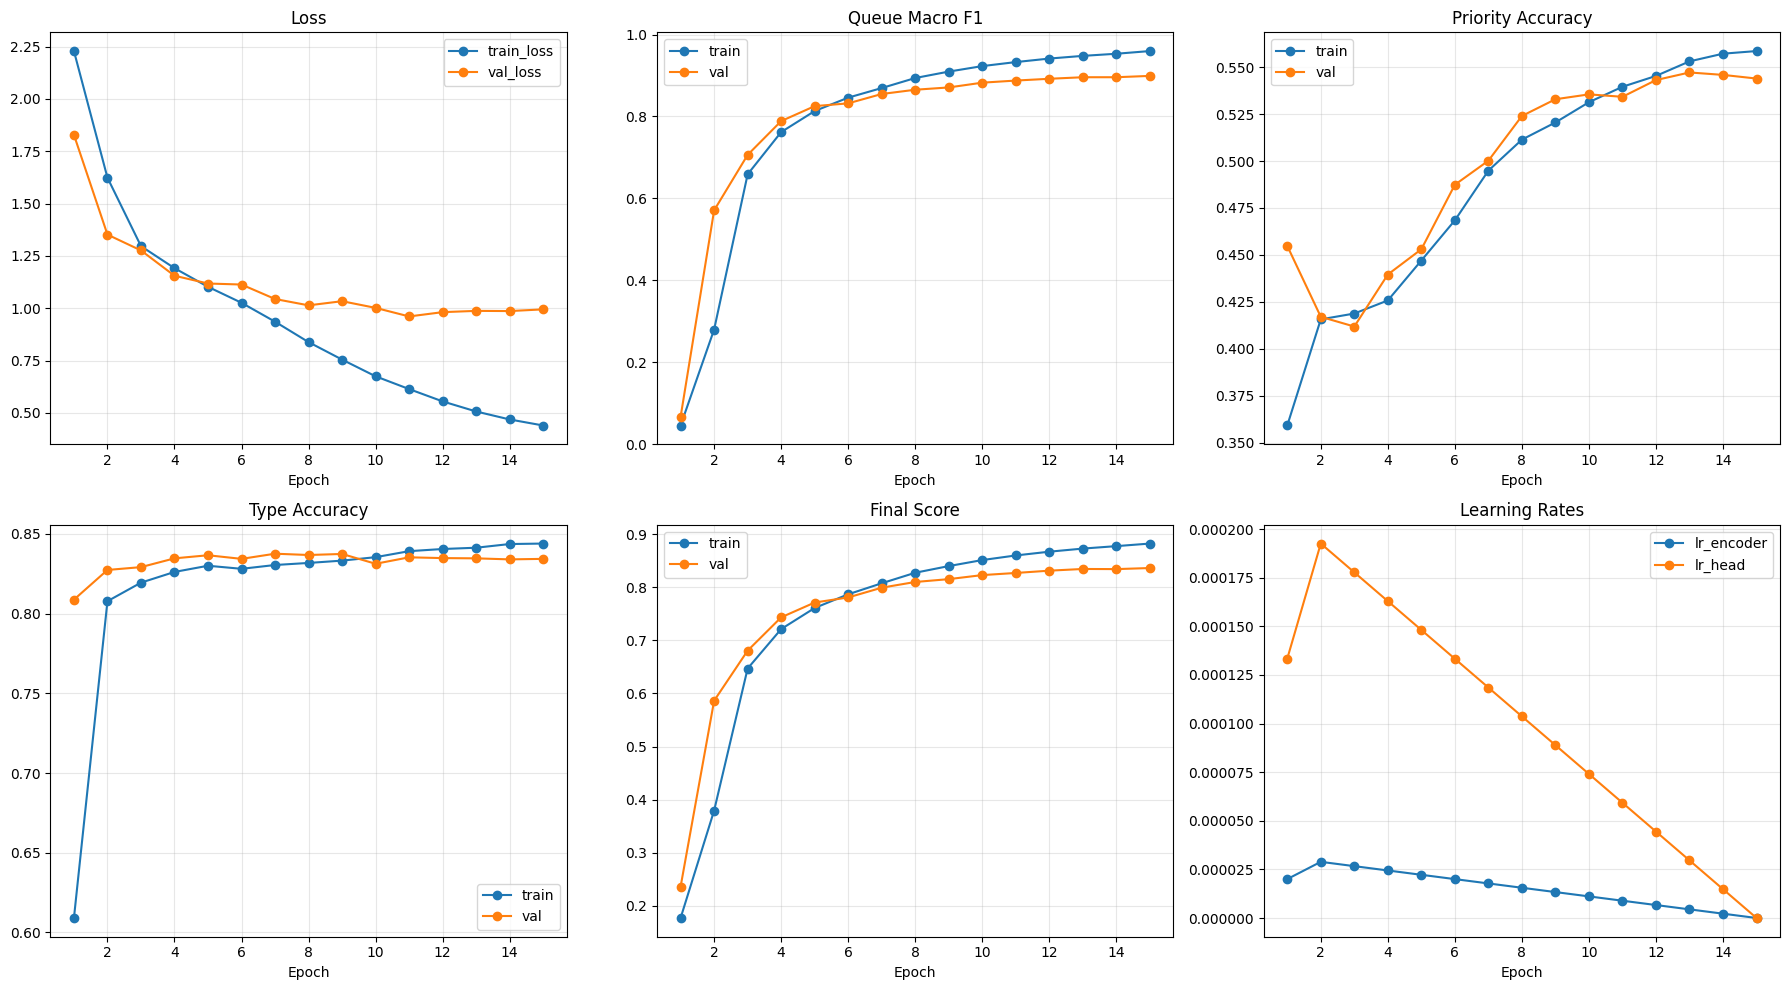

,epoch,epoch_time_sec,lr_encoder,lr_head,train_loss,train_loss_queue,train_loss_priority,train_loss_type,train_queue_acc,train_queue_macro_f1,...,train_final_score,queue_acc,queue_macro_f1,priority_acc,type_acc,final_score,eval_loss,eval_loss_queue,eval_loss_priority,eval_loss_type
0,1,304.9630,0.0,0.0001,2.2284,2.5144,1.2590,0.9103,0.2461,0.0457,...,0.1772,0.3099,0.0668,0.4548,0.8088,0.2363,1.8281,2.0976,1.0962,0.4039
1,2,302.9579,0.0,0.0002,1.6235,1.8360,1.1487,0.3981,0.3715,0.2799,...,0.3795,0.4756,0.5708,0.4171,0.8274,0.5862,1.3516,1.5014,1.1546,0.3504
2,3,303.4706,0.0,0.0002,1.2965,1.4307,1.1590,0.3608,0.4888,0.6588,...,0.6469,0.5091,0.7062,0.4119,0.8292,0.6805,1.2760,1.4077,1.1508,0.3471
3,4,303.4559,0.0,0.0002,1.1912,1.3028,1.1410,0.3488,0.5284,0.7619,...,0.7211,0.5499,0.7887,0.4396,0.8347,0.7432,1.1551,1.2627,1.1187,0.3306
4,5,301.1230,0.0,0.0001,1.1021,1.1971,1.1070,0.3377,0.5600,0.8132,...,0.7608,0.5606,0.8252,0.4530,0.8366,0.7711,1.1179,1.2203,1.0903,0.3267
5,6,301.3769,0.0,0.0001,1.0258,1.1074,1.0616,0.3373,0.5956,0.8459,...,0.7866,0.5609,0.8320,0.4874,0.8344,0.7806,1.1130,1.2199,1.0380,0.3332
6,7,301.1619,0.0,0.0001,0.9355,1.0009,1.0153,0.3331,0.6329,0.8693,...,0.8073,0.5936,0.8548,0.5002,0.8376,0.7990,1.0439,1.1401,0.9963,0.3222
7,8,301.2652,0.0,0.0001,0.8380,0.8844,0.9772,0.3278,0.6785,0.8938,...,0.8271,0.6247,0.8652,0.5240,0.8368,0.8098,1.0136,1.1060,0.9631,0.3256
8,9,301.6549,0.0,0.0001,0.7544,0.7825,0.9579,0.3265,0.7200,0.9095,...,0.8397,0.6282,0.8708,0.5329,0.8374,0.8151,1.0335,1.1324,0.9513,0.3243
9,10,301.1068,0.0,0.0001,0.6746,0.6852,0.9414,0.3233,0.7573,0.9229,...,0.8510,0.6512,0.8824,0.5355,0.8313,0.8227,1.0015,1.0924,0.9432,0.3327


epoch_time=5.01 min | train_loss=0.4397 | val_loss=0.9945 | train_final_score=0.8821 | val_final_score=0.8360
[BEST] Saved checkpoint to outputs_mdeberta_v2\best_mdeberta_multitask.pt | final_score=0.8360

Training history:


,epoch,epoch_time_sec,lr_encoder,lr_head,train_loss,train_loss_queue,train_loss_priority,train_loss_type,train_queue_acc,train_queue_macro_f1,...,train_final_score,queue_acc,queue_macro_f1,priority_acc,type_acc,final_score,eval_loss,eval_loss_queue,eval_loss_priority,eval_loss_type
0,1,304.9630,0.0,0.0001,2.2284,2.5144,1.2590,0.9103,0.2461,0.0457,...,0.1772,0.3099,0.0668,0.4548,0.8088,0.2363,1.8281,2.0976,1.0962,0.4039
1,2,302.9579,0.0,0.0002,1.6235,1.8360,1.1487,0.3981,0.3715,0.2799,...,0.3795,0.4756,0.5708,0.4171,0.8274,0.5862,1.3516,1.5014,1.1546,0.3504
2,3,303.4706,0.0,0.0002,1.2965,1.4307,1.1590,0.3608,0.4888,0.6588,...,0.6469,0.5091,0.7062,0.4119,0.8292,0.6805,1.2760,1.4077,1.1508,0.3471
3,4,303.4559,0.0,0.0002,1.1912,1.3028,1.1410,0.3488,0.5284,0.7619,...,0.7211,0.5499,0.7887,0.4396,0.8347,0.7432,1.1551,1.2627,1.1187,0.3306
4,5,301.1230,0.0,0.0001,1.1021,1.1971,1.1070,0.3377,0.5600,0.8132,...,0.7608,0.5606,0.8252,0.4530,0.8366,0.7711,1.1179,1.2203,1.0903,0.3267
5,6,301.3769,0.0,0.0001,1.0258,1.1074,1.0616,0.3373,0.5956,0.8459,...,0.7866,0.5609,0.8320,0.4874,0.8344,0.7806,1.1130,1.2199,1.0380,0.3332
6,7,301.1619,0.0,0.0001,0.9355,1.0009,1.0153,0.3331,0.6329,0.8693,...,0.8073,0.5936,0.8548,0.5002,0.8376,0.7990,1.0439,1.1401,0.9963,0.3222
7,8,301.2652,0.0,0.0001,0.8380,0.8844,0.9772,0.3278,0.6785,0.8938,...,0.8271,0.6247,0.8652,0.5240,0.8368,0.8098,1.0136,1.1060,0.9631,0.3256
8,9,301.6549,0.0,0.0001,0.7544,0.7825,0.9579,0.3265,0.7200,0.9095,...,0.8397,0.6282,0.8708,0.5329,0.8374,0.8151,1.0335,1.1324,0.9513,0.3243
9,10,301.1068,0.0,0.0001,0.6746,0.6852,0.9414,0.3233,0.7573,0.9229,...,0.8510,0.6512,0.8824,0.5355,0.8313,0.8227,1.0015,1.0924,0.9432,0.3327



Loading best checkpoint for final test evaluation...


Eval Epoch TEST/FINAL:   0%|          | 0/97 [00:00<?, ?it/s]

...

Predict:   0%|          | 0/97 [00:00<?, ?it/s]


===== QUEUE CLASSIFICATION REPORT =====


,precision,recall,f1-score,support
Arts & Entertainment/Movies,0.9615,0.9615,0.9615,26.000
Arts & Entertainment/Music,0.9600,1.0000,0.9796,24.000
Autos & Vehicles/Maintenance,1.0000,0.9615,0.9804,26.000
Autos & Vehicles/Sales,1.0000,1.0000,1.0000,38.000
Beauty & Fitness/Cosmetics,1.0000,0.9583,0.9787,24.000
Beauty & Fitness/Fitness Training,1.0000,1.0000,1.0000,26.000
Billing and Payments,0.7832,0.8421,0.8116,532.000
Books & Literature/Fiction,0.9643,0.9643,0.9643,28.000
Books & Literature/Non-Fiction,1.0000,0.9444,0.9714,36.000
Business & Industrial/Manufacturing,1.0000,1.0000,1.0000,33.000



===== TOP-10 WORST QUEUE CLASSES BY F1 =====


,precision,recall,f1-score,support
General Inquiry,0.4800,0.3810,0.4248,63.0
Sales and Pre-Sales,0.5088,0.4203,0.4603,138.0
Human Resources,0.5806,0.3956,0.4706,91.0
Customer Service,0.5420,0.5144,0.5278,766.0
Returns and Exchanges,0.5767,0.5103,0.5415,243.0
Product Support,0.5977,0.4963,0.5423,937.0
IT Support,0.5204,0.5942,0.5549,515.0
Technical Support,0.6254,0.6876,0.6550,1418.0
Service Outages and Maintenance,0.6335,0.7609,0.6914,184.0
Billing and Payments,0.7832,0.8421,0.8116,532.0


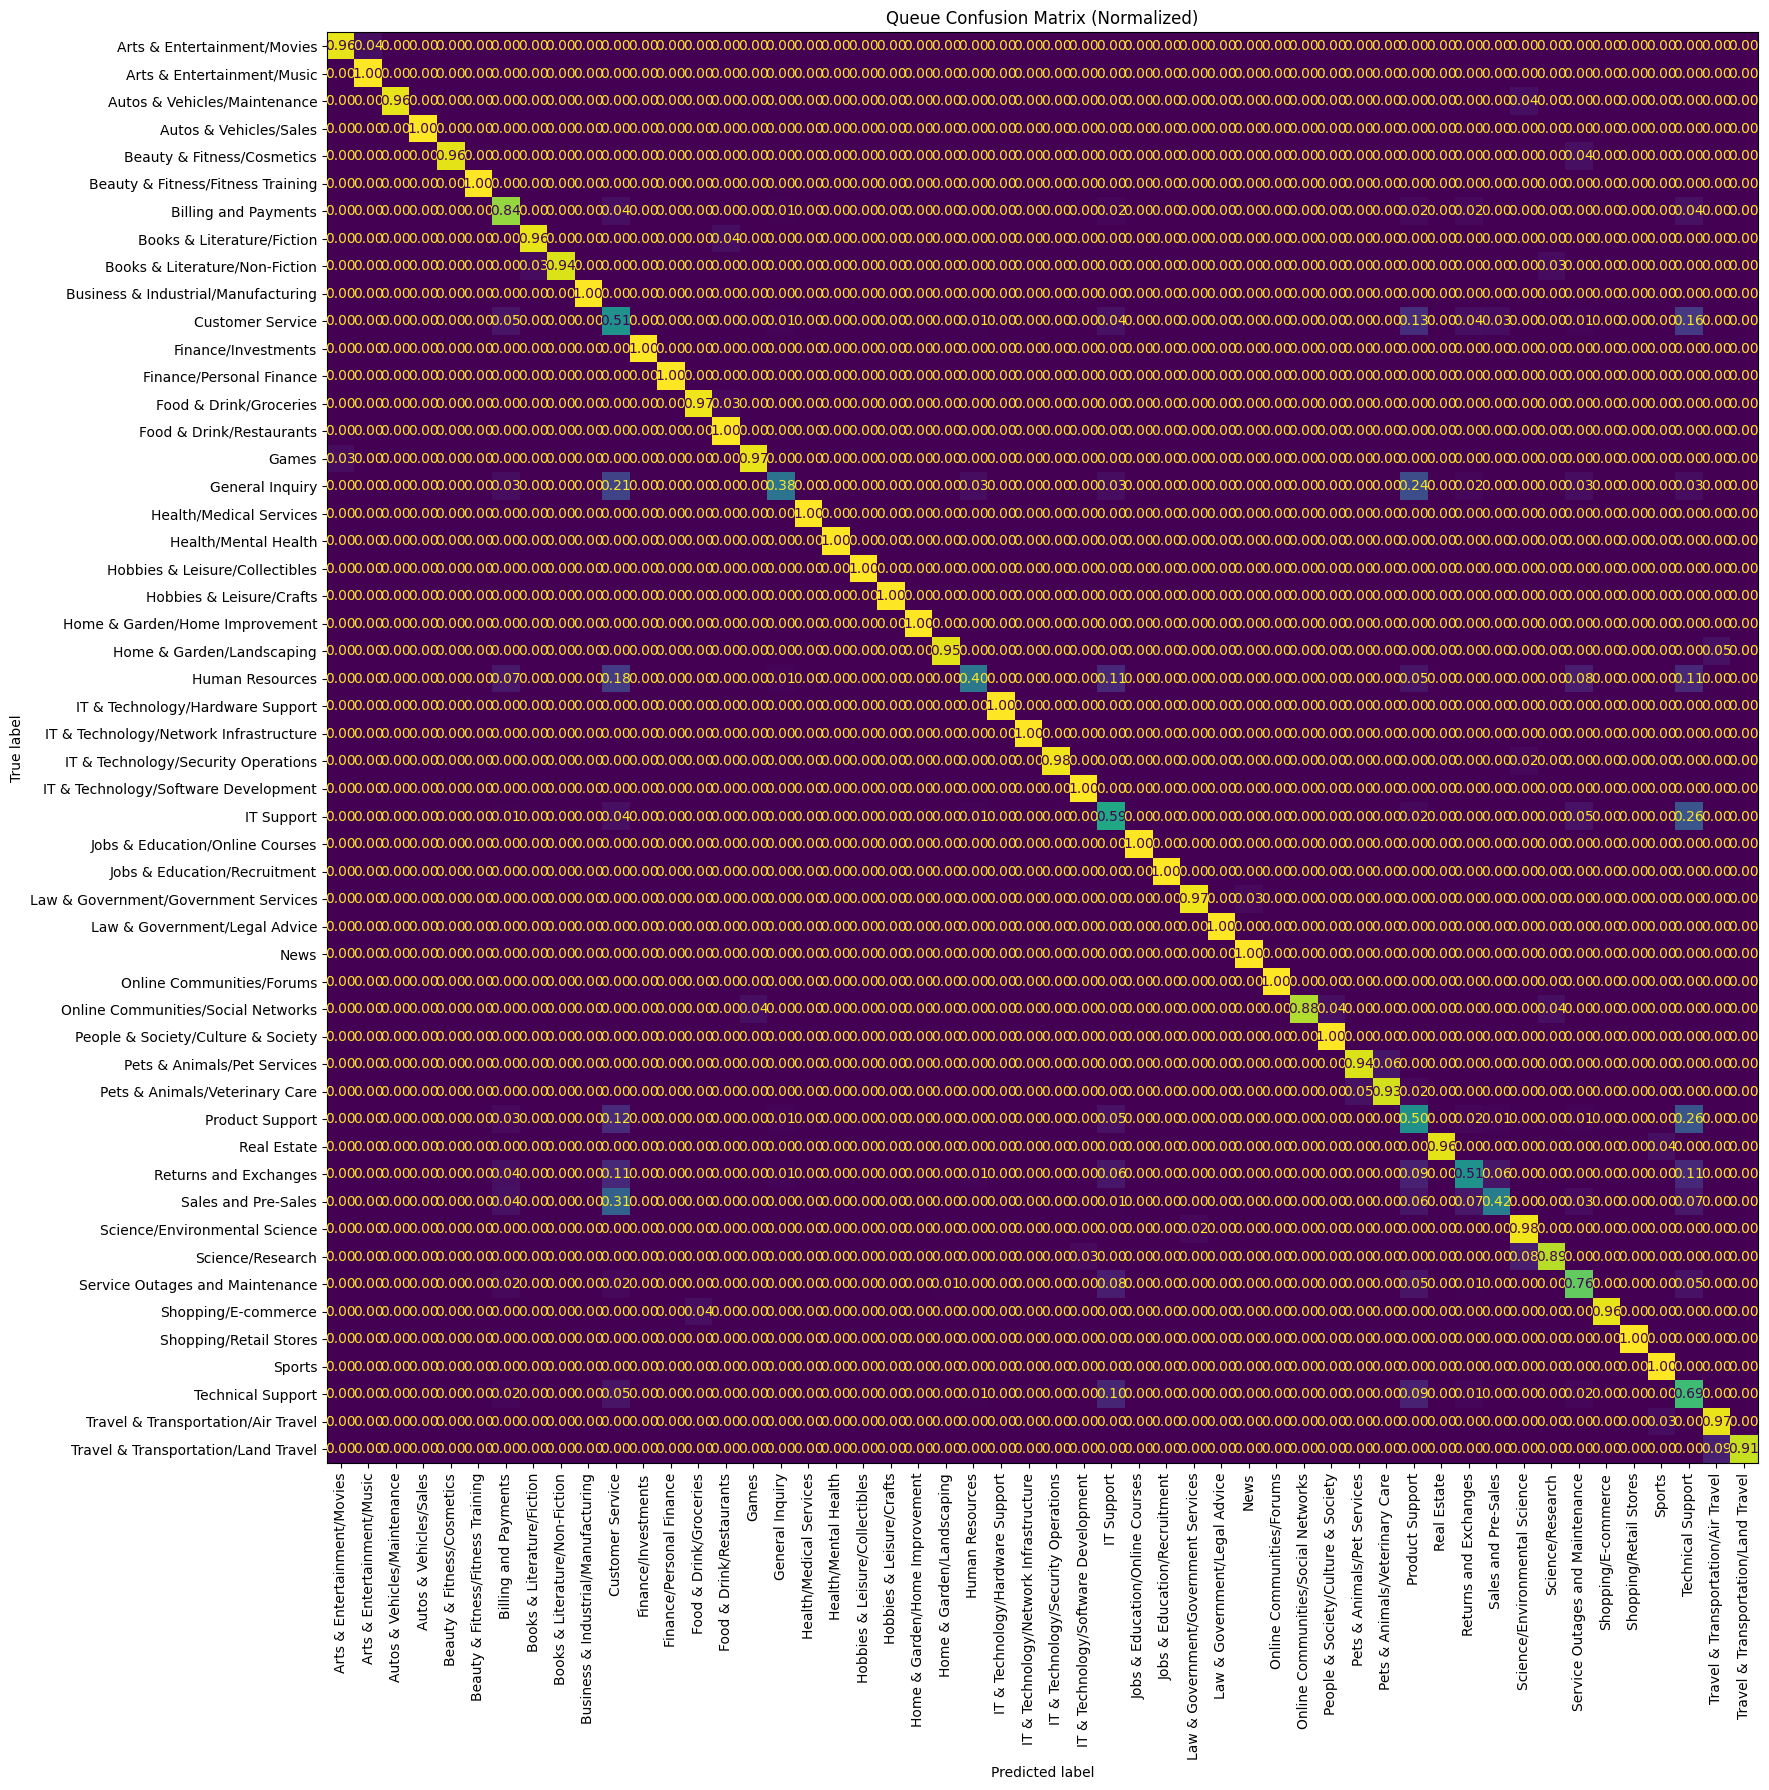


===== TOP-20 MOST CONFIDENT QUEUE ERRORS =====


,language,subject,body,queue_true,queue_pred,queue_confidence,queue_margin,priority_true,priority_pred,type_true,type_pred
1838,en,Significant Service Interruption Impacting Dig...,The agency experienced downtime that impacted ...,Technical Support,Service Outages and Maintenance,1.000000,0.999918,high,high,Incident,Incident
4161,de,Notwendige technische Unterstützung,"Viele Werkzeuge funktionierten zeitgleich aus,...",IT Support,Service Outages and Maintenance,1.000000,0.999870,high,high,Problem,Incident
3037,de,Anfrage bezüglich Änderung der Öffnungszeiten ...,"Guten Tag, Support-Team,\n\nich schreibe Ihnen...",Online Communities/Social Networks,Games,1.000000,0.999685,low,very_low,Unknown,Unknown
398,en,Report of Data Access Disruptions for Healthca...,Customer Support reports experiencing disrupti...,IT Support,Service Outages and Maintenance,1.000000,0.999569,medium,high,Problem,Incident
1004,en,Security Concern Raised Regarding Data Breach,Assistance Required,Product Support,Billing and Payments,1.000000,0.999550,low,medium,Incident,Problem
556,de,Fehlerhafte Digitale Werkzeuge Verursachen Täg...,"Sehr geehrter Kundenservice, ich möchte ein te...",Technical Support,IT Support,1.000000,0.998543,high,high,Incident,Incident
1684,de,"Leistungsstörungen, Wachstum beeinträchtigen","ich schreibe, um Hilfe bei der Behebung von Le...",Service Outages and Maintenance,Technical Support,1.000000,0.998543,high,high,Change,Incident
225,en,Support Service Issue,A ticket has been created to address a support...,IT Support,Service Outages and Maintenance,1.000000,0.998405,medium,high,Incident,Change
5528,en,Guidance for Integrating Project Management So...,"Hello Customer Support, I am writing to inquir...",Customer Service,Billing and Payments,0.996094,0.995338,medium,medium,Request,Request
4606,de,Unterstützung für Alteryx-Investitionsoptimier...,"Sehr geehrte Kundensupport, ich schreibe, um I...",Technical Support,Billing and Payments,0.996094,0.994827,medium,medium,Request,Request



===== TOP CONFUSION PAIRS (QUEUE) =====


,queue_true,queue_pred,count
0,Product Support,Technical Support,243
1,Technical Support,IT Support,148
2,IT Support,Technical Support,135
3,Technical Support,Product Support,130
4,Customer Service,Technical Support,126
5,Product Support,Customer Service,113
6,Customer Service,Product Support,100
7,Technical Support,Customer Service,74
8,Product Support,IT Support,47
9,Sales and Pre-Sales,Customer Service,43



Saved:
outputs_mdeberta_v2\queue_classification_report.csv
outputs_mdeberta_v2\queue_worst_classes.csv
outputs_mdeberta_v2\queue_errors_full.csv
outputs_mdeberta_v2\queue_confusion_pairs.csv
outputs_mdeberta_v2\test_predictions_full.csv

Artifacts:
Best checkpoint: outputs_mdeberta_v2\best_mdeberta_multitask.pt
History CSV: outputs_mdeberta_v2\history.csv


In [9]:
if __name__ == "__main__":
    artifacts = main()